# DATA ARCHITECTURE AND QUALITY CONTROL

we are working with the data that contains the dual markers so might be good to filter
checks are at donor level

- data correction methods?

**Output: Adjusted dataset and baseline integration statistics**

Data Quality Measures:
- Donor-Level Consistency Analysis: Quantify which donors systematically over- or under-apply markers.
- Missing Value Assessment: Measure the prevalence of missing markers across donors, countries, and sectors, and apply imputation or correction.
- Text Mining Validation: Use NLP on project descriptions to identify substantive vs. superficial integration, cross-checking marker accuracy.
- Composite Indicators: Combine markers with sector codes, purpose codes, and channels of delivery to create a multidimensional “integration score.”

###############################################################################

1. DATA ARCHITECTURE:
- checking schema and metadata
- checking data type
- verify sector codes are mapped correctly
- determine level of granularity of the data
- identify if ID is unique to project

2. DATA QUALITY CONTROL AND CLEANING
- check and quantify missing values
- especially for the critial fields
- validate numeric ranges (are there negatives for disbursements or received?)
- years that don't make sense
- duplicate projects/transactions
- use descriptive stats to identify outliers and anomalies
- integrity checks (where disbursed is higher then committed by large gap?)

In [1]:
#!pip install  plotly

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from pathlib import Path
import gc
from typing import Dict, List, Tuple, Optional
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import dask.dataframe as dd
import duckdb
import os
from dask.diagnostics import ProgressBar
import math

C:\Users\user\anaconda3\lib\site-packages\pandas\core\computation\expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.8.3' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
C:\Users\user\anaconda3\lib\site-packages\pandas\core\arrays\masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


In [4]:
# Configuration for memory optimization
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)

# Memory optimization settings
CHUNK_SIZE = 30000  # Reduced for M4 MacBook
MAX_CATEGORIES = 50  # Limit categorical analysis


## DATA LOADING

In [6]:
DATA_PATH = "D:/my_projects/undp/data/"

In [7]:
class MemoryOptimizedLoader:
    """Optimized data loader for large datasets"""

    @staticmethod
    def load_chunked_csv(filepath: str, chunk_size: int = CHUNK_SIZE) -> Optional[pd.DataFrame]:
        """Load large CSV in memory-efficient chunks"""
        try:
            print(f"Loading {filepath} in chunks of {chunk_size}...")
            chunks = []
            total_rows = 0

            for chunk in pd.read_csv(filepath, chunksize=chunk_size, low_memory=False):
                # Basic cleaning during load
                chunk = chunk.dropna(subset=['Year', 'USD_Disbursement'])
                chunks.append(chunk)
                total_rows += len(chunk)

                if len(chunks) % 10 == 0:
                    print(f"Processed {total_rows:,} rows...")

            df = pd.concat(chunks, ignore_index=True)
            print(f"Successfully loaded {len(df):,} rows")
            return df

        except FileNotFoundError:
            print(f"Error: File {filepath} not found")
            return None
        except Exception as e:
            print(f"Error loading {filepath}: {e}")
            return None

    @staticmethod
    def optimize_dtypes(df: pd.DataFrame) -> pd.DataFrame:
        """Optimize data types to reduce memory usage"""
        print("Optimizing data types...")
        initial_memory = df.memory_usage(deep=True).sum() / 1024**2

        # Convert numeric columns
        numeric_cols = df.select_dtypes(include=[np.number]).columns
        for col in numeric_cols:
            if df[col].dtype == 'float64':
                df[col] = pd.to_numeric(df[col], downcast='float')
            elif df[col].dtype == 'int64':
                df[col] = pd.to_numeric(df[col], downcast='integer')

        # Convert categorical columns
        categorical_threshold = 0.5
        for col in df.select_dtypes(include=['object']).columns:
            if len(df[col].unique()) / len(df) < categorical_threshold:
                df[col] = df[col].astype('category')

        final_memory = df.memory_usage(deep=True).sum() / 1024**2
        print(f"Memory usage reduced from {initial_memory:.1f}MB to {final_memory:.1f}MB")
        print(f"Reduction: {((initial_memory - final_memory) / initial_memory * 100):.1f}%")

        return df


In [8]:
# Initialize data loader
loader = MemoryOptimizedLoader()

# Load main CRS dataset
print("\n1. LOADING PRIMARY DATASET (OECD CRS)")

crs_data = loader.load_chunked_csv(DATA_PATH + 'crs_data.csv')

if crs_data is not None:
    # Optimize memory usage
    crs_data = loader.optimize_dtypes(crs_data)

    print(f"\nCRS Dataset Overview:")
    print(f"Shape: {crs_data.shape}")
    print(f"Memory usage: {crs_data.memory_usage(deep=True).sum() / 1024**2:.1f} MB")
    print(f"Time range: {crs_data['Year'].min()} - {crs_data['Year'].max()}")





1. LOADING PRIMARY DATASET (OECD CRS)
Loading D:/my_projects/undp/data/crs_data.csv in chunks of 30000...
Processed 280,468 rows...
Processed 566,686 rows...
Processed 846,597 rows...
Processed 1,113,955 rows...
Processed 1,394,358 rows...
Processed 1,675,196 rows...
Processed 1,963,728 rows...
Processed 2,247,398 rows...
Processed 2,528,521 rows...
Processed 2,810,827 rows...
Processed 3,061,335 rows...
Processed 3,324,607 rows...
Successfully loaded 3,538,825 rows
Optimizing data types...
Memory usage reduced from 12453.1MB to 2010.0MB
Reduction: 83.9%

CRS Dataset Overview:
Shape: (3538825, 98)
Memory usage: 2010.0 MB
Time range: 2014 - 2023


## 2. DATA CLEANING 

In [9]:
crs_data.head(5)

,Year,DonorCode,DEDonorcode,DonorName,AgencyCode,AgencyName,CrsID,ProjectNumber,InitialReport,RecipientCode,DERecipientcode,RecipientName,RegionCode,DERegioncode,RegionName,IncomegroupCode,DEIncomegroupCode,IncomegroupName,FlowCode,FlowName,Bi_Multi,Category,Finance_T,Aid_T,USD_Commitment,USD_Disbursement,USD_Received,USD_Commitment_Defl,USD_Disbursement_Defl,USD_Received_Defl,USD_Adjustment,USD_Adjustment_Defl,USD_AmountUntied,USD_AmountPartialTied,USD_AmountTied,USD_AmountUntied_Defl,USD_AmountPartialTied_Defl,USD_Amounttied_Defl,USD_IRTC,USD_Expert_Commitment,USD_Expert_Extended,USD_Export_Credit,CurrencyCode,Commitment_National,Disbursement_National,GrantEquiv,USD_GrantEquiv,ShortDescription,ProjectTitle,PurposeCode,PurposeName,SectorCode,SectorName,ChannelCode,ChannelName,ChannelReportedName,ParentChannelCode,Geography,LDCflag,LDCflagName,ExpectedStartDate,CompletionDate,LongDescription,SDGfocus,Keywords,Gender,Environment,DIG,Trade,RMNCH,DRR,Nutrition,Disability,FTC,PBA,InvestmentProject,BlendedFinanceType,Biodiversity,ClimateMitigation,ClimateAdaptation,Desertification,CommitmentDate,TypeRepayment,NumberRepayment,Interest1,Interest2,Repaydate1,Repaydate2,USD_Interest,USD_Outstanding,USD_Arrears_Principal,USD_Arrears_Interest,CapitalExpend,PSIflag,PSIflagName,PSIAddType,PSIAddDesc,PSIAddDevObj
0,2014,5,DEU,Germany,7.0,Federal Foreign Office,2014008560,6607565,8.0,139,TUN,Tunisia,10002,F4,North of Sahara,10018,LMIC,LMICs,11,ODA Grants,1.0,10.0,110,C01,0.161292,0.161292,0.0,0.154159,0.154159,0.0,NaN,NaN,0.0,NaN,0.161292,0.0,NaN,0.154159,NaN,NaN,NaN,NaN,302.0,0.161292,0.161292,NaN,NaN,STRENGTHENING OF LEGAL AID SERVICES,Strengthening of legal aid services,15130,Legal and judicial development,151,I.5.a. Government & Civil Society-general,22000.0,Donor country-based NGO,Donor country-based NGO,22000.0,NaN,NaN,NaN,2014-08-15,2014-12-31,Provide criminal defense services to indigent ...,NaN,NaN,1.0,0.0,2.0,NaN,0.0,NaN,NaN,NaN,1.0,NaN,NaN,NaN,0.0,0.0,0.0,0.0,2014-08-15,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN
1,2014,5,DEU,Germany,7.0,Federal Foreign Office,2014008562,6607567,1.0,625,AFG,Afghanistan,10009,S4_S7,South & Central Asia,10016,LDC,LDCs,11,ODA Grants,1.0,10.0,110,C01,4.385697,1.953164,0.0,4.191745,1.866788,0.0,NaN,NaN,4.385697,NaN,0.0,4.191745,NaN,0.0,NaN,NaN,NaN,NaN,302.0,4.385697,1.953164,NaN,NaN,NaN,NaN,73010,Immediate post-emergency reconstruction and re...,730,VIII.2. Reconstruction Relief & Rehabilitation,90000.0,Other,Other,90000.0,NaN,NaN,NaN,2014-08-01,2014-12-31,NaN,NaN,NaN,1.0,1.0,2.0,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,2014-08-01,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN
2,2014,5,DEU,Germany,7.0,Federal Foreign Office,2014008563,6607568,1.0,9998,DPGC_X,"Bilateral, unspecified",15006,DPGC_X,Regional and Unspecified,10024,INC_X,Part I unallocated by income,11,ODA Grants,1.0,10.0,110,E01,0.690275,0.105570,0.0,0.659748,0.100901,0.0,NaN,NaN,0.0,NaN,0.690275,0.0,NaN,0.659748,NaN,NaN,NaN,NaN,302.0,0.690275,0.105570,NaN,NaN,SCHOLARSHIPS FOR FOREIGN STUDENTS,Scholarships for foreign students,11420,Higher education,114,I.1.d. Post-Secondary Education,22000.0,Donor country-based NGO,Donor country-based NGO,22000.0,NaN,NaN,NaN,2014-01-01,2014-12-31,"Development of educated classes in society, pr...",NaN,NaN,0.0,0.0,0.0,NaN,0.0,NaN,NaN,NaN,1.0,NaN,NaN,NaN,0.0,0.0,0.0,0.0,2014-01-01,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN
3,2014,5,DEU,Germany,7.0,Federal Foreign Office,2014008564,6607570,8.0,9998,DPGC_X,"Bilateral, unspecified",15006,DPGC_X,Regional and Unspecified,10024,INC_X,Part I unallocated by income,11,ODA Grants,1.0,10.0,110,C01,0.050500,0.050500,0.0,0.048266,0.048266,0.0,NaN,NaN,0.0505,NaN,0.0,0.048266,NaN,0.0,NaN,NaN,NaN,NaN,302.0,0.050500,0.050500,NaN,NaN,POLITICAL PROCESS OF ENERGY TRANSITION,Political process of energy transition,23181,Energy education/training,231,II.3.a. Energy Policy,10000.0,Public Sector Institutions,GIZ,10

In [10]:
#checking for missing values
missing_share = (crs_data.isna().mean()).sort_values(ascending=False)
print("Missing share by column:\n", missing_share)

Missing share by column:
 USD_Export_Credit        0.999714
PSIAddDesc               0.997058
PSIAddDevObj             0.996596
PSIAddType               0.995239
BlendedFinanceType       0.994749
                           ...   
IncomegroupCode          0.000000
USD_Disbursement         0.000000
USD_Disbursement_Defl    0.000000
DonorCode                0.000000
Year                     0.000000
Length: 98, dtype: float64


In [11]:
missing_share.to_csv("missing_share.csv",index=True)

In [12]:
#drop columns with more than 70% missing data
crs_data = crs_data.drop(missing_share[missing_share > 0.7].index, axis=1)

In [13]:
# Additional columns to drop based on relevance
irrelevant_cols = [
    'USD_Commitment_Defl', 'USD_Disbursement_Defl', 'USD_Received_Defl', 'USD_AmountUntied_Defl',
    'USD_AmountPartialTied_Defl', 'USD_Amounttied_Defl', 'USD_GrantEquiv', 'ParentChannelCode'
]
crs_data = crs_data.drop(columns=irrelevant_cols)

In [14]:
print(len(crs_data.columns))

56


In [15]:
crs_data.columns.to_list()

['Year',
 'DonorCode',
 'DEDonorcode',
 'DonorName',
 'AgencyCode',
 'AgencyName',
 'CrsID',
 'ProjectNumber',
 'InitialReport',
 'RecipientCode',
 'DERecipientcode',
 'RecipientName',
 'RegionCode',
 'DERegioncode',
 'RegionName',
 'IncomegroupCode',
 'DEIncomegroupCode',
 'IncomegroupName',
 'FlowCode',
 'FlowName',
 'Bi_Multi',
 'Category',
 'Finance_T',
 'Aid_T',
 'USD_Commitment',
 'USD_Disbursement',
 'USD_Received',
 'USD_AmountUntied',
 'USD_AmountPartialTied',
 'USD_AmountTied',
 'CurrencyCode',
 'Commitment_National',
 'Disbursement_National',
 'GrantEquiv',
 'ShortDescription',
 'ProjectTitle',
 'PurposeCode',
 'PurposeName',
 'SectorCode',
 'SectorName',
 'ChannelCode',
 'ChannelName',
 'ChannelReportedName',
 'ExpectedStartDate',
 'CompletionDate',
 'LongDescription',
 'SDGfocus',
 'Gender',
 'Environment',
 'DIG',
 'RMNCH',
 'Biodiversity',
 'ClimateMitigation',
 'ClimateAdaptation',
 'Desertification',
 'CommitmentDate']

In [16]:
crs_data.head(4)

,Year,DonorCode,DEDonorcode,DonorName,AgencyCode,AgencyName,CrsID,ProjectNumber,InitialReport,RecipientCode,DERecipientcode,RecipientName,RegionCode,DERegioncode,RegionName,IncomegroupCode,DEIncomegroupCode,IncomegroupName,FlowCode,FlowName,Bi_Multi,Category,Finance_T,Aid_T,USD_Commitment,USD_Disbursement,USD_Received,USD_AmountUntied,USD_AmountPartialTied,USD_AmountTied,CurrencyCode,Commitment_National,Disbursement_National,GrantEquiv,ShortDescription,ProjectTitle,PurposeCode,PurposeName,SectorCode,SectorName,ChannelCode,ChannelName,ChannelReportedName,ExpectedStartDate,CompletionDate,LongDescription,SDGfocus,Gender,Environment,DIG,RMNCH,Biodiversity,ClimateMitigation,ClimateAdaptation,Desertification,CommitmentDate
0,2014,5,DEU,Germany,7.0,Federal Foreign Office,2014008560,6607565,8.0,139,TUN,Tunisia,10002,F4,North of Sahara,10018,LMIC,LMICs,11,ODA Grants,1.0,10.0,110,C01,0.161292,0.161292,0.0,0.0,NaN,0.161292,302.0,0.161292,0.161292,NaN,STRENGTHENING OF LEGAL AID SERVICES,Strengthening of legal aid services,15130,Legal and judicial development,151,I.5.a. Government & Civil Society-general,22000.0,Donor country-based NGO,Donor country-based NGO,2014-08-15,2014-12-31,Provide criminal defense services to indigent ...,NaN,1.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0,2014-08-15
1,2014,5,DEU,Germany,7.0,Federal Foreign Office,2014008562,6607567,1.0,625,AFG,Afghanistan,10009,S4_S7,South & Central Asia,10016,LDC,LDCs,11,ODA Grants,1.0,10.0,110,C01,4.385697,1.953164,0.0,4.385697,NaN,0.0,302.0,4.385697,1.953164,NaN,NaN,NaN,73010,Immediate post-emergency reconstruction and re...,730,VIII.2. Reconstruction Relief & Rehabilitation,90000.0,Other,Other,2014-08-01,2014-12-31,NaN,NaN,1.0,1.0,2.0,0.0,0.0,0.0,0.0,0.0,2014-08-01
2,2014,5,DEU,Germany,7.0,Federal Foreign Office,2014008563,6607568,1.0,9998,DPGC_X,"Bilateral, unspecified",15006,DPGC_X,Regional and Unspecified,10024,INC_X,Part I unallocated by income,11,ODA Grants,1.0,10.0,110,E01,0.690275,0.105570,0.0,0.0,NaN,0.690275,302.0,0.690275,0.105570,NaN,SCHOLARSHIPS FOR FOREIGN STUDENTS,Scholarships for foreign students,11420,Higher education,114,I.1.d. Post-Secondary Education,22000.0,Donor country-based NGO,Donor country-based NGO,2014-01-01,2014-12-31,"Development of educated classes in society, pr...",NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2014-01-01
3,2014,5,DEU,Germany,7.0,Federal Foreign Office,2014008564,6607570,8.0,9998,DPGC_X,"Bilateral, unspecified",15006,DPGC_X,Regional and Unspecified,10024,INC_X,Part I unallocated by income,11,ODA Grants,1.0,10.0,110,C01,0.050500,0.050500,0.0,0.0505,NaN,0.0,302.0,0.050500,0.050500,NaN,POLITICAL PROCESS OF ENERGY TRANSITION,Political process of energy transition,23181,Energy education/training,231,II.3.a. Energy Policy,10000.0,Public Sector Institutions,GIZ,2014-09-01,2014-12-31,Concentrated insight of the international part...,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2014-09-01


In [17]:
#check the existing data types
print(crs_data.dtypes)

Year                        int16
DonorCode                   int16
DEDonorcode              category
DonorName                category
AgencyCode                float32
AgencyName               category
CrsID                    category
ProjectNumber            category
InitialReport             float32
RecipientCode            category
DERecipientcode          category
RecipientName            category
RegionCode               category
DERegioncode             category
RegionName               category
IncomegroupCode          category
DEIncomegroupCode        category
IncomegroupName          category
FlowCode                 category
FlowName                 category
Bi_Multi                  float32
Category                  float32
Finance_T                category
Aid_T                    category
USD_Commitment            float32
USD_Disbursement          float32
USD_Received              float32
USD_AmountUntied         category
USD_AmountPartialTied     float32
USD_AmountTied

In [18]:
crs_data['Finance_T'].unique()

[110, 421, 510, 611, 610, ..., 1101, 4221, NaN, 1.0, 0.0]
Length: 51
Categories (50, object): [0.0, 1.0, 110, 210, ..., '612', '615', '618', 'B03']

In [19]:
numeric_cols = [
    'Year','USD_Commitment','USD_Disbursement','USD_Received',
    'Commitment_National','Disbursement_National'
]

cat_cols = ['DonorCode','RecipientCode','RegionCode','IncomegroupCode',
            'PurposeCode','SectorCode','ChannelCode','ParentChannelCode','FlowCode','FlowName',
            'Bi_Multi','Category','Finance_T','Aid_T','CurrencyCode']

str_cols = ['RecipientName','RegionName','IncomegroupName','ShortDescription','ProjectTitle','PurposeName','SectorName','ChannelName','ChannelReportedName','LongDescription']

marker_cols = ["Gender","ClimateMitigation","ClimateAdaptation","Environment","DIG","RMNCH","Biodiversity"]

In [20]:
for col in numeric_cols:
    if col in crs_data.columns:
        crs_data[col] = crs_data[col].astype('float64')

In [21]:
# Convert development marker columns to nullable integer type
for c in marker_cols:
    if c in crs_data.columns:
        crs_data[c] = pd.to_numeric(crs_data[c], errors="coerce").astype("Int8")

In [22]:
#converting code columns to categories
for col in cat_cols:
    if col in crs_data.columns:
        crs_data[col] = crs_data[col].astype('category')

In [23]:
#Define the co‑benefit buckets
both    = (crs_data["Gender"]>0) & ((crs_data["ClimateMitigation"]>0)|(crs_data["ClimateAdaptation"]>0))
gender  = (crs_data["Gender"]>0) & ~both
climate = (~gender) & ((crs_data["ClimateMitigation"]>0)|(crs_data["ClimateAdaptation"]>0))

crs_data["Bucket"] = "Neither"
crs_data.loc[gender,  "Bucket"] = "Only gender"
crs_data.loc[climate, "Bucket"] = "Only climate"
crs_data.loc[both,    "Bucket"] = "Both"

In [24]:
crs_data.head(3)

,Year,DonorCode,DEDonorcode,DonorName,AgencyCode,AgencyName,CrsID,ProjectNumber,InitialReport,RecipientCode,DERecipientcode,RecipientName,RegionCode,DERegioncode,RegionName,IncomegroupCode,DEIncomegroupCode,IncomegroupName,FlowCode,FlowName,Bi_Multi,Category,Finance_T,Aid_T,USD_Commitment,USD_Disbursement,USD_Received,USD_AmountUntied,USD_AmountPartialTied,USD_AmountTied,CurrencyCode,Commitment_National,Disbursement_National,GrantEquiv,ShortDescription,ProjectTitle,PurposeCode,PurposeName,SectorCode,SectorName,ChannelCode,ChannelName,ChannelReportedName,ExpectedStartDate,CompletionDate,LongDescription,SDGfocus,Gender,Environment,DIG,RMNCH,Biodiversity,ClimateMitigation,ClimateAdaptation,Desertification,CommitmentDate,Bucket
0,2014.0,5,DEU,Germany,7.0,Federal Foreign Office,2014008560,6607565,8.0,139,TUN,Tunisia,10002,F4,North of Sahara,10018,LMIC,LMICs,11,ODA Grants,1.0,10.0,110,C01,0.161292,0.161292,0.0,0.0,NaN,0.161292,302.0,0.161292,0.161292,NaN,STRENGTHENING OF LEGAL AID SERVICES,Strengthening of legal aid services,15130,Legal and judicial development,151,I.5.a. Government & Civil Society-general,22000.0,Donor country-based NGO,Donor country-based NGO,2014-08-15,2014-12-31,Provide criminal defense services to indigent ...,NaN,1,0,2,0,0,0,0,0.0,2014-08-15,Only gender
1,2014.0,5,DEU,Germany,7.0,Federal Foreign Office,2014008562,6607567,1.0,625,AFG,Afghanistan,10009,S4_S7,South & Central Asia,10016,LDC,LDCs,11,ODA Grants,1.0,10.0,110,C01,4.385697,1.953164,0.0,4.385697,NaN,0.0,302.0,4.385697,1.953164,NaN,NaN,NaN,73010,Immediate post-emergency reconstruction and re...,730,VIII.2. Reconstruction Relief & Rehabilitation,90000.0,Other,Other,2014-08-01,2014-12-31,NaN,NaN,1,1,2,0,0,0,0,0.0,2014-08-01,Only gender
2,2014.0,5,DEU,Germany,7.0,Federal Foreign Office,2014008563,6607568,1.0,9998,DPGC_X,"Bilateral, unspecified",15006,DPGC_X,Regional and Unspecified,10024,INC_X,Part I unallocated by income,11,ODA Grants,1.0,10.0,110,E01,0.690275,0.105570,0.0,0.0,NaN,0.690275,302.0,0.690275,0.105570,NaN,SCHOLARSHIPS FOR FOREIGN STUDENTS,Scholarships for foreign students,11420,Higher education,114,I.1.d. Post-Secondary Education,22000.0,Donor country-based NGO,Donor country-based NGO,2014-01-01,2014-12-31,"Development of educated classes in society, pr...",NaN,0,0,0,0,0,0,0,0.0,2014-01-01,Neither


In [25]:
#drop duplicates
crs_data = crs_data.drop_duplicates()

In [26]:
print(crs_data.shape)

(3488417, 57)


In [27]:
crs_data[pd.isna(crs_data["ProjectNumber"])]

,Year,DonorCode,DEDonorcode,DonorName,AgencyCode,AgencyName,CrsID,ProjectNumber,InitialReport,RecipientCode,DERecipientcode,RecipientName,RegionCode,DERegioncode,RegionName,IncomegroupCode,DEIncomegroupCode,IncomegroupName,FlowCode,FlowName,Bi_Multi,Category,Finance_T,Aid_T,USD_Commitment,USD_Disbursement,USD_Received,USD_AmountUntied,USD_AmountPartialTied,USD_AmountTied,CurrencyCode,Commitment_National,Disbursement_National,GrantEquiv,ShortDescription,ProjectTitle,PurposeCode,PurposeName,SectorCode,SectorName,ChannelCode,ChannelName,ChannelReportedName,ExpectedStartDate,CompletionDate,LongDescription,SDGfocus,Gender,Environment,DIG,RMNCH,Biodiversity,ClimateMitigation,ClimateAdaptation,Desertification,CommitmentDate,Bucket
37,2014.0,5,DEU,Germany,4.0,Deutsche Investitions- und Entwicklungsgesells...,NaN,NaN,NaN,298,F_X,"Africa, regional",298,F_X,"Africa, regional",10024,INC_X,Part I unallocated by income,14,Other Official Flows (non Export Credit),1.0,21.0,421,NaN,126.199524,126.199524,0.000000,126.199523,NaN,0.0,302.0,126.199524,126.199524,NaN,Semi-aggregates,NaN,200,II. Economic Infrastructure & Services,200,II. Economic Infrastructure & Services,NaN,NaN,NaN,NaN,NaN,NaN,NaN,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,NaN,NaN,Neither
38,2014.0,5,DEU,Germany,4.0,Deutsche Investitions- und Entwicklungsgesells...,NaN,NaN,NaN,298,F_X,"Africa, regional",298,F_X,"Africa, regional",10024,INC_X,Part I unallocated by income,14,Other Official Flows (non Export Credit),1.0,21.0,421,NaN,69.340454,69.340454,0.000000,69.340452,NaN,0.0,302.0,69.340454,69.340454,NaN,Semi-aggregates,NaN,300,III. Production Sectors,300,III. Production Sectors,NaN,NaN,NaN,NaN,NaN,NaN,NaN,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,NaN,NaN,Neither
39,2014.0,5,DEU,Germany,4.0,Deutsche Investitions- und Entwicklungsgesells...,NaN,NaN,NaN,498,A_X,"America, regional",498,A_X,"America, regional",10024,INC_X,Part I unallocated by income,14,Other Official Flows (non Export Credit),1.0,21.0,421,NaN,103.384712,103.384712,0.000000,103.384715,NaN,0.0,302.0,103.384712,103.384712,NaN,Semi-aggregates,NaN,200,II. Economic Infrastructure & Services,200,II. Economic Infrastructure & Services,NaN,NaN,NaN,NaN,NaN,NaN,NaN,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,NaN,NaN,Neither
40,2014.0,5,DEU,Germany,4.0,Deutsche Investitions- und Entwicklungsgesells...,NaN,NaN,NaN,498,A_X,"America, regional",498,A_X,"America, regional",10024,INC_X,Part I unallocated by income,14,Other Official Flows (non Export Credit),1.0,21.0,421,NaN,68.601143,68.601143,0.000000,68.601146,NaN,0.0,302.0,68.601143,68.601143,NaN,Semi-aggregates,NaN,300,III. Production Sectors,300,III. Production Sectors,NaN,NaN,NaN,NaN,NaN,NaN,NaN,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,NaN,NaN,Neither
41,2014.0,5,DEU,Germany,4.0,Deutsche Investitions- und Entwicklungsgesells...,NaN,NaN,NaN,798,S_X,"Asia, regional",798,S_X,"Asia, regional",10024,INC_X,Part I unallocated by income,14,Other Official Flows (non Export Credit),1.0,21.0,421,NaN,209.725693,209.725693,0.000000,209.725692,NaN,0.0,302.0,209.725693,209.725693,NaN,Semi-aggregates,NaN,200,II. Economic Infrastructure & Services,200,II. Economic Infrastructure & Services,NaN,NaN,NaN,NaN,NaN,NaN,NaN,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,NaN,NaN,Neither
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2792379,2023.0,1054,9OTH023,World Organisation for Animal Health,2.0,Statutory contribution and voluntary contribut...,2023000148,NaN,3.0,89,E_X,"Europe, regional",10010,E,Europe,10024,INC_X,Part I unallocated by income,11,ODA Grants,4.0,10.0,110,D02,NaN,0.043544,NaN,NaN,NaN,NaN,918.0,NaN,0.040269,NaN,SUB-REGIONAL R EPRESENTATION IN BRUSSELS - DEV...,Sub-Regional R epresentation in Brussels - Dev...,31195,Livestock/veterinary services,311,III.1.a. Agriculture,47148.0,World Organisation for Animal Health,WOAH,NaN,NaN,Expenses pertaini

In [28]:
#9% of the data does not have a project number

# 1. GRANULARITY CHECK

In [29]:
def check_granularity_simple(
    df: pd.DataFrame,
    year_col: str = "Year",
    donor_col: str = "DonorName",
    sector_col: str = "SectorName",
    purpose_col: str = "PurposeName",
    channel_col: str = "ChannelCode",
    recipient_col: str = "RecipientName",
    date_cols: Tuple[str, ...] = ("CommitmentDate", "ExpectedStartDate", "CompletionDate"),
) -> Dict:
    """
    Simple, readable granularity checker for CRS-like data.
    - Picks ProjectNumber as project key if present, else CrsID.
    - Shows uniqueness for ID and a few useful composite keys.
    - Summarizes how many donors/channels/sectors/years per project.
    - Warns if CrsID <-> ProjectNumber mapping is many-to-many.
    - Sniffs date precision and suggests an aggregation level.
    Returns a dict and also prints a friendly summary.
    """

    report: Dict = {}
    n_rows = len(df)
    if n_rows == 0:
        print("Empty DataFrame.")
        return {"rows": 0}

    # 1) Choose primary project ID (prefer ProjectNumber)
    has_proj = "ProjectNumber" in df.columns
    has_crs  = "CrsID" in df.columns
    primary_id: str = "ProjectNumber" if has_proj else ("CrsID" if has_crs else "")
    alt_id: Optional[str] = ("CrsID" if (has_proj and has_crs) else None)

    if not primary_id:
        print("Neither 'ProjectNumber' nor 'CrsID' found.")
        return {"rows": n_rows}

    # 2) Uniqueness for ID and a few composites
    def uniq_ratio(cols: List[str]) -> Tuple[int, int, float]:
        u = int(df[cols].drop_duplicates().shape[0])
        return u, n_rows, u / n_rows

    id_unique = {primary_id: uniq_ratio([primary_id])}
    if alt_id:
        id_unique[alt_id] = uniq_ratio([alt_id])

    comp_keys = []
    for c in [year_col, donor_col, channel_col, sector_col, purpose_col]:
        if c in df.columns:
            comp_keys.append((primary_id, c))
    for pair in [(year_col, donor_col), (year_col, channel_col), (year_col, sector_col)]:
        a, b = pair
        if {primary_id, a, b}.issubset(df.columns):
            comp_keys.append((primary_id, a, b))

    comp_unique = {key: uniq_ratio(list(key)) for key in comp_keys}

    # 3) Multi-row stats per project + splits per project
    vc = df[primary_id].value_counts(dropna=False)
    multi_stats = dict(
        id_col=primary_id,
        projects_with_multiple_rows=int((vc > 1).sum()),
        max_rows_per_id=int(vc.max()),
        median_rows_per_id=float(vc.median()),
        mean_rows_per_id=float(vc.mean()),
    )

    splits = {}
    for dim in [year_col, donor_col, channel_col, sector_col, purpose_col, recipient_col]:
        if dim in df.columns:
            desc = df.groupby(primary_id)[dim].nunique(dropna=True).describe()
            splits[dim] = {k: float(v) if isinstance(v, (int, float)) else v for k, v in desc.items()}

    # 4) ID mapping integrity (if both present)
    mapping = {}
    warnings = []
    if has_proj and has_crs:
        c2p = df.groupby("CrsID")["ProjectNumber"].nunique(dropna=True)
        p2c = df.groupby("ProjectNumber")["CrsID"].nunique(dropna=True)
        mapping = {
            "CrsID_to_ProjectNumber": {
                ">1 targets": int((c2p > 1).sum()),
                "max_targets": int(c2p.max()),
                "share_with_>1": float((c2p > 1).mean()),
            },
            "ProjectNumber_to_CrsID": {
                ">1 sources": int((p2c > 1).sum()),
                "max_sources": int(p2c.max()),
                "share_with_>1": float((p2c > 1).mean()),
            },
        }
        if (c2p > 1).any():
            warnings.append("CrsID maps to multiple ProjectNumber values → use ProjectNumber as the primary key.")
        if (p2c > 1).any():
            warnings.append("ProjectNumber maps to multiple CrsID values → verify de-duplication rules before joins.")

    # 5) Date precision sniff
    date_prec = {}
    for dc in date_cols:
        if dc in df.columns:
            ser = df[dc]
            looks_detailed = ser.astype(str).str.contains("-").mean() if ser.notna().any() else 0.0
            date_prec[dc] = dict(
                non_null_share=float(ser.notna().mean()),
                looks_daily_or_monthly=bool(looks_detailed > 0.5),
            )

    # 6) Heuristic: likely row meaning & recommendation
    likely = "Granularity is mixed; multiple rows per project indicate within-project splits."
    reco = f"Aggregate to ({primary_id}, {year_col}) for time series, or {primary_id} for project-level indicators."

    prim_ratio = id_unique[primary_id][2]
    if prim_ratio > 0.95:
        likely = f"Each row looks like a unique {primary_id} record (near-unique)."
        reco = f"Analyze at {primary_id} level or aggregate minimally."
    else:
        key_py = (primary_id, year_col)
        if key_py in comp_unique and comp_unique[key_py][2] > 0.95:
            likely = f"Rows look unique at {primary_id}-{year_col} level (one row per project-year)."
            reco = f"Aggregate to ({primary_id}, {year_col}) before summing amounts to avoid double counting."
        else:
            for key in [
                (primary_id, year_col, donor_col),
                (primary_id, year_col, channel_col),
                (primary_id, year_col, sector_col),
                (primary_id, donor_col),
                (primary_id, channel_col),
                (primary_id, sector_col),
            ]:
                if all(isinstance(k, str) and (k in df.columns if k != primary_id else True) for k in key):
                    if key in comp_unique and comp_unique[key][2] > 0.95:
                        dims_str = ", ".join([k for k in key[1:]])
                        likely = f"Rows appear split at {dims_str} within projects."
                        reco = f"Aggregate to ({primary_id}, {year_col}) (or {primary_id} if not time-based) before totals."
                        break

    if any(v.get("looks_daily_or_monthly") for v in date_prec.values()):
        reco += " Daily/monthly dates present—bucket by month or year before financial sums."

    # 7) Assemble & print
    report = dict(
        rows=n_rows,
        primary_id=primary_id,
        alternate_id=alt_id,
        id_uniqueness=id_unique,
        composite_uniqueness=comp_unique,
        multi_rows_per_id=multi_stats,
        splits_per_id=splits,
        id_mapping_integrity=mapping,
        date_precision=date_prec,
        likely_row_meaning=likely,
        recommendation=reco,
        warnings=warnings,
    )

    # print results
    print("=== Granularity Check (simple) ===")
    print(f"Rows: {n_rows:,} | Primary ID: {primary_id}" + (f" | Alternate ID: {alt_id}" if alt_id else ""))
    for k, (u, total, r) in id_unique.items():
        print(f"- {k}: {u:,} unique / {total:,} rows (ratio={r:.3f})")
    for key, (u, total, r) in comp_unique.items():
        print(f"- {key}: {u:,} unique combos / {total:,} rows (ratio={r:.3f})")
    m = multi_stats
    print(f"- {m['id_col']} multi-rows → projects>1row: {m['projects_with_multiple_rows']:,}, "
          f"max rows per ID: {m['max_rows_per_id']}, median: {m['median_rows_per_id']:.1f}")
    if mapping:
        print("- ID mapping integrity:")
        for side, stats in mapping.items():
            print(f"  • {side}: {stats}")
    if warnings:
        print("Warnings:")
        for w in warnings:
            print("  •", w)
    print(f"→ Likely granularity: {likely}")
    print(f"→ Recommendation: {reco}")

    return report

In [30]:
check_granularity_simple(crs_data)

=== Granularity Check (simple) ===
Rows: 3,488,417 | Primary ID: ProjectNumber | Alternate ID: CrsID
- ProjectNumber: 955,627 unique / 3,488,417 rows (ratio=0.274)
- CrsID: 1,304,073 unique / 3,488,417 rows (ratio=0.374)
- ('ProjectNumber', 'Year'): 1,703,164 unique combos / 3,488,417 rows (ratio=0.488)
- ('ProjectNumber', 'DonorName'): 968,886 unique combos / 3,488,417 rows (ratio=0.278)
- ('ProjectNumber', 'ChannelCode'): 1,092,027 unique combos / 3,488,417 rows (ratio=0.313)
- ('ProjectNumber', 'SectorName'): 1,116,440 unique combos / 3,488,417 rows (ratio=0.320)
- ('ProjectNumber', 'PurposeName'): 1,190,711 unique combos / 3,488,417 rows (ratio=0.341)
- ('ProjectNumber', 'Year', 'DonorName'): 1,713,531 unique combos / 3,488,417 rows (ratio=0.491)
- ('ProjectNumber', 'Year', 'ChannelCode'): 1,728,610 unique combos / 3,488,417 rows (ratio=0.496)
- ('ProjectNumber', 'Year', 'SectorName'): 1,863,787 unique combos / 3,488,417 rows (ratio=0.534)
- ProjectNumber multi-rows → projects>1row

{'rows': 3488417,
 'primary_id': 'ProjectNumber',
 'alternate_id': 'CrsID',
 'id_uniqueness': {'ProjectNumber': (955627, 3488417, 0.27394288010865675),
  'CrsID': (1304073, 3488417, 0.3738294475689116)},
 'composite_uniqueness': {('ProjectNumber', 'Year'): (1703164,
   3488417,
   0.4882340614668487),
  ('ProjectNumber', 'DonorName'): (968886, 3488417, 0.27774374451219563),
  ('ProjectNumber', 'ChannelCode'): (1092027, 3488417, 0.3130437100839722),
  ('ProjectNumber', 'SectorName'): (1116440, 3488417, 0.3200420133258151),
  ('ProjectNumber', 'PurposeName'): (1190711, 3488417, 0.34133275924294604),
  ('ProjectNumber', 'Year', 'DonorName'): (1713531,
   3488417,
   0.4912058965427585),
  ('ProjectNumber', 'Year', 'ChannelCode'): (1728610,
   3488417,
   0.4955284875632701),
  ('ProjectNumber', 'Year', 'SectorName'): (1863787,
   3488417,
   0.534278728718499)},
 'multi_rows_per_id': {'id_col': 'ProjectNumber',
  'projects_with_multiple_rows': 388720,
  'max_rows_per_id': 655641,
  'media

In [31]:
def qc_project_splits(
    df: pd.DataFrame,
    project_col: str = "ProjectNumber",
    donor_col: str = "DonorName",
    channel_col: str = "ChannelCode",
    sector_col: str = "SectorName",
    donor_threshold: int = 10,
    top_n: int = 10
) -> pd.DataFrame:
    """
    QC check: summarize project-level splits and visualize top pooled projects.
    Returns a DataFrame with counts and a pooled_flag column.
    """
    # --- 1) Aggregate counts per project ---
    agg = (
        df.groupby(project_col)[[donor_col, channel_col, sector_col]]
          .nunique(dropna=True)
          .rename(columns={donor_col: "n_donors",
                           channel_col: "n_channels",
                           sector_col: "n_sectors"})
    )

    # --- 2) Flag pooled projects ---
    agg["pooled_flag"] = agg["n_donors"] > donor_threshold

    # --- 3) Plot top projects by donor count ---
    top_projects = agg.sort_values("n_donors", ascending=False).head(top_n)
    ax = top_projects["n_donors"].plot(
        kind="barh", figsize=(8, 5), color=["tomato" if x > donor_threshold else "steelblue" for x in top_projects["n_donors"]]
    )
    ax.set_xlabel("# Unique Donors")
    ax.set_ylabel(project_col)
    ax.set_title(f"Top {top_n} Projects by Donor Diversity\n(> {donor_threshold} donors flagged as pooled)")
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()

    return agg.reset_index()

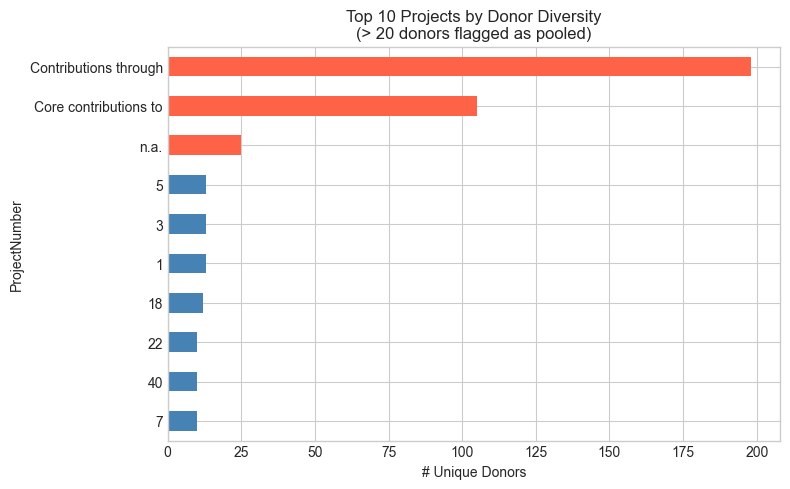

,ProjectNumber,n_donors,n_channels,n_sectors,pooled_flag
0,'020B10,1,1,1,False
1,'035C01,1,1,1,False
2,'045L01,1,1,1,False
3,'045L02,1,1,1,False
4,'048E02,1,1,1,False


In [32]:
qc_table = qc_project_splits(crs_data, donor_threshold=20, top_n=10)
qc_table.head()

In [33]:
dims = crs_data.groupby("ProjectNumber")[["DonorName","ChannelCode","SectorName"]].nunique()
dims = dims.sort_values("DonorName", ascending=False).head(10)
print(dims)

                       DonorName  ChannelCode  SectorName
ProjectNumber                                            
Contributions through        198            0           0
Core contributions to        105            0           0
n.a.                          25          101          31
5                             13           22          19
3                             13           27          28
1                             13           23          30
18                            12           15          13
22                            10           12          12
40                            10           10          14
7                             10           17          18


In [34]:
no_id = crs_data[crs_data['ProjectNumber']=='n.a.']
print(no_id['DonorName'].unique())
no_id.head(5)

['MAVA Foundation', 'Gatsby Charitable Foundation', 'H&M Foundation', 'Margaret A. Cargill Foundation', 'Jacobs Foundation', ..., 'Arcadia Fund', 'Susan T. Buffett Foundation', 'LEGO Foundation', 'Bloomberg Family Foundation', 'Bezos Earth Fund']
Length: 25
Categories (382, object): ['Abu Dhabi Department of Finance', 'Abu Dhabi Fund for Development', 'Adaptation Fund', 'African Development Bank', ..., 'World Organisation for Animal Health', 'World Tourism Organisation', 'World Trade Organisation', 'Youth and Sports Ministry']


,Year,DonorCode,DEDonorcode,DonorName,AgencyCode,AgencyName,CrsID,ProjectNumber,InitialReport,RecipientCode,DERecipientcode,RecipientName,RegionCode,DERegioncode,RegionName,IncomegroupCode,DEIncomegroupCode,IncomegroupName,FlowCode,FlowName,Bi_Multi,Category,Finance_T,Aid_T,USD_Commitment,USD_Disbursement,USD_Received,USD_AmountUntied,USD_AmountPartialTied,USD_AmountTied,CurrencyCode,Commitment_National,Disbursement_National,GrantEquiv,ShortDescription,ProjectTitle,PurposeCode,PurposeName,SectorCode,SectorName,ChannelCode,ChannelName,ChannelReportedName,ExpectedStartDate,CompletionDate,LongDescription,SDGfocus,Gender,Environment,DIG,RMNCH,Biodiversity,ClimateMitigation,ClimateAdaptation,Desertification,CommitmentDate,Bucket
20,2014.0,1610,9PRIV1610,MAVA Foundation,1.0,MAVA Foundation,2014000021,n.a.,8.0,9998,DPGC_X,"Bilateral, unspecified",15006,DPGC_X,Regional and Unspecified,10024,INC_X,Part I unallocated by income,30,Private Development Finance,6.0,30.0,110,D02,0.543169,0.543169,NaN,NaN,NaN,NaN,11.0,0.4970,0.4970,NaN,GRANTEE NOT SPECIFIED,Grantee not specified,41082,Environmental research,410,IV.1. General Environment Protection,32000.0,Networks,Network,NaN,NaN,Programme: Sustainable Economy. Finance for Ch...,NaN,0,2,0,0,0,0,0,0.0,2014-01-01,Neither
21,2014.0,1610,9PRIV1610,MAVA Foundation,1.0,MAVA Foundation,2014000022,n.a.,8.0,9998,DPGC_X,"Bilateral, unspecified",15006,DPGC_X,Regional and Unspecified,10024,INC_X,Part I unallocated by income,30,Private Development Finance,6.0,30.0,110,D02,0.674863,0.674863,NaN,NaN,NaN,NaN,11.0,0.6175,0.6175,NaN,GRANTEE NOT SPECIFIED,Grantee not specified,41082,Environmental research,410,IV.1. General Environment Protection,22000.0,Donor country-based NGO,Donor country-based NGO,NaN,NaN,Programme: Sustainable Economy. A toolkit for ...,NaN,0,2,0,0,0,0,0,0.0,2014-01-01,Neither
22,2014.0,1610,9PRIV1610,MAVA Foundation,1.0,MAVA Foundation,2014000023,n.a.,8.0,9998,DPGC_X,"Bilateral, unspecified",15006,DPGC_X,Regional and Unspecified,10024,INC_X,Part I unallocated by income,30,Private Development Finance,6.0,30.0,110,D02,0.546448,0.546448,NaN,NaN,NaN,NaN,11.0,0.5000,0.5000,NaN,GRANTEE NOT SPECIFIED,Grantee not specified,41010,Environmental policy and administrative manage...,410,IV.1. General Environment Protection,51000.0,"University, college or other teaching institut...","University, college or other teaching institut...",NaN,NaN,Programme: Sustainable Economy. Forging Sustai...,NaN,0,2,0,0,0,0,0,0.0,2014-01-01,Neither
23,2014.0,1610,9PRIV1610,MAVA Foundation,1.0,MAVA Foundation,2014000024,n.a.,8.0,9998,DPGC_X,"Bilateral, unspecified",15006,DPGC_X,Regional and Unspecified,10024,INC_X,Part I unallocated by income,30,Private Development Finance,6.0,30.0,110,D02,2.073770,2.073770,NaN,NaN,NaN,NaN,11.0,1.8975,1.8975,NaN,GRANTEE NOT SPECIFIED,Grantee not specified,41082,Environmental research,410,IV.1. General Environment Protection,51000.0,"University, college or other teaching institut...","University, college or other teaching institut...",NaN,NaN,Programme: Sustainable Economy. The Hoffmann C...,NaN,0,2,0,0,0,0,0,0.0,2014-01-01,Neither
24,2014.0,1610,9PRIV1610,MAVA Foundation,1.0,MAVA Foundation,2014000025,n.a.,8.0,9998,DPGC_X,"Bilateral, unspecified",15006,DPGC_X,Regional and Unspecified,10024,INC_X,Part I unallocated by income,30,Private Development Finance,6.0,30.0,110,D02,0.054645,0.054645,NaN,NaN,NaN,NaN,11.0,0.0500,0.0500,NaN,GRANTEE NOT SPECIFIED,Grantee not specified,41030,Biodiversity,410,IV.1. General Environment Protection,23000.0,Developing country-based NGO,Recipient country-based NGO,NaN,NaN,Programme: Global. Conservation Finance Pavili...,NaN,0,2,0,0,2,0,0,0.0,2014-01-01,Neither


In [35]:
#projects with more than one donor
if {"ProjectNumber","DonorName"}.issubset(crs_data.columns):
    donors_per_project = crs_data.groupby("CrsID")["ProjectNumber"].nunique()
    print("Projects with >1 donor:", (donors_per_project > 1).sum())


Projects with >1 donor: 209017


# DONOR-LEVEL CONSISTENCY ANALYSIS

In [36]:
buckets = ["Both","Gender only","Climate only","Neither"]

In [37]:
keys = ["ProjectNumber","Year","DonorName",'SectorName','RecipientName']
marker_cols = ["Gender","ClimateMitigation","ClimateAdaptation"]
cols = keys + marker_cols + (["Bucket"] if "Bucket" in crs_data.columns else [])

df = crs_data[cols].copy()

# Ensure numeric markers (coerce bad values -> NaN)
for c in marker_cols:
    if c in df:
        df[c] = pd.to_numeric(df[c], errors="coerce")

# Collapse to project-year-donor for markers
agg = (df.groupby(keys, observed=True, sort=False)[marker_cols]
         .mean()              # presence logic; if you prefer mean, swap to .mean()
         .reset_index())

project_year_donor = agg 


In [38]:
both    = (project_year_donor["Gender"]>0) & ((crs_data["ClimateMitigation"]>0)|(crs_data["ClimateAdaptation"]>0))
gender  = (project_year_donor["Gender"]>0) & ~both
climate = (~gender) & ((project_year_donor["ClimateMitigation"]>0)|(project_year_donor["ClimateAdaptation"]>0))

project_year_donor["Bucket"] = "Neither"
project_year_donor.loc[gender,  "Bucket"] = "Only gender"
project_year_donor.loc[climate, "Bucket"] = "Only climate"
project_year_donor.loc[both,    "Bucket"] = "Both"

In [39]:
buckets = ['Neither',"Only gender","Only climate",'Both']

In [40]:
project_year_donor['Bucket'].value_counts(normalize=True)

Bucket
Neither         0.642237
Only gender     0.280279
Only climate    0.048230
Both            0.029254
Name: proportion, dtype: float64

In [41]:
project_year_donor.shape

(2094300, 9)

In [42]:
project_year_donor.head()

,ProjectNumber,Year,DonorName,SectorName,RecipientName,Gender,ClimateMitigation,ClimateAdaptation,Bucket
0,6607565,2014.0,Germany,I.5.a. Government & Civil Society-general,Tunisia,1.0,0.0,0.0,Only gender
1,6607567,2014.0,Germany,VIII.2. Reconstruction Relief & Rehabilitation,Afghanistan,1.0,0.0,0.0,Only gender
2,6607568,2014.0,Germany,I.1.d. Post-Secondary Education,"Bilateral, unspecified",0.0,0.0,0.0,Neither
3,6607570,2014.0,Germany,II.3.a. Energy Policy,"Bilateral, unspecified",0.0,0.0,0.0,Neither
4,6607571,2014.0,Germany,I.5.a. Government & Civil Society-general,"Bilateral, unspecified",1.0,0.0,0.0,Only gender


In [43]:
project_year_donor[project_year_donor[['ProjectNumber', 'Year','DonorName']].duplicated() == True]

,ProjectNumber,Year,DonorName,SectorName,RecipientName,Gender,ClimateMitigation,ClimateAdaptation,Bucket
21,n.a.,2014.0,MAVA Foundation,IV.1. General Environment Protection,Zambia,0.0,0.0,0.0,Neither
23,11589425,2014.0,MetLife Foundation,II.4. Banking & Financial Services,India,0.0,0.0,0.0,Neither
29,2666,2014.0,Conrad N. Hilton Foundation,I.4. Water Supply & Sanitation,Mali,0.0,0.0,0.0,Neither
305,142745,2014.0,Charity Projects Ltd (Comic Relief),I.1.c. Secondary Education,Rwanda,0.0,0.0,0.0,Neither
306,142745,2014.0,Charity Projects Ltd (Comic Relief),I.2.b. Basic Health,Rwanda,0.0,0.0,0.0,Neither
...,...,...,...,...,...,...,...,...,...
2094289,300552-103,2023.0,United Kingdom,I.6. Other Social Infrastructure & Services,"Asia, regional",1.0,0.0,0.0,Only gender
2094291,203385-105,2023.0,United Kingdom,I.6. Other Social Infrastructure & Services,Nepal,<NA>,<NA>,<NA>,Neither
2094297,204607-102,2023.0,United Kingdom,I.3. Population Policies/Programmes & Reproduc...,Pakistan,0.0,<NA>,<NA>,Neither
2094298,204607-102,2023.0,United Kingdom,I.5.a. Government & Civil Society-general,Pakistan,0.0,<NA>,<NA>,Neither


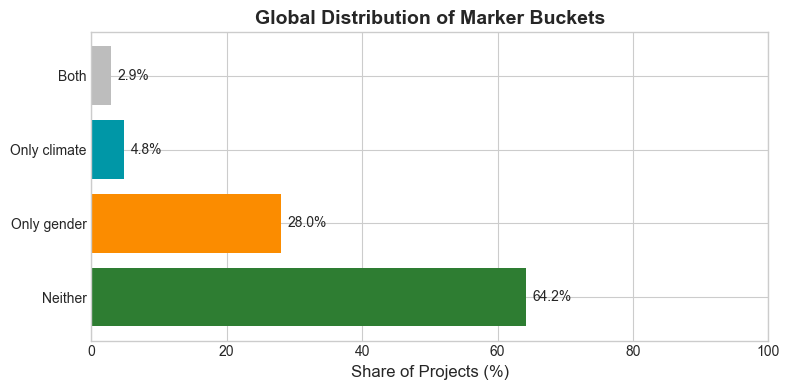

Bucket
Neither         64.2
Only gender     28.0
Only climate     4.8
Both             2.9
Name: proportion, dtype: float64


In [44]:
def plot_global_bucket_distribution(project_year_donor, bucket_col="Bucket"):
    # Ensure consistent bucket order
    #buckets = ["Both","Gender Only","Climate Only","Neither"]
    global_dist = (project_year_donor[bucket_col]
                   .value_counts(normalize=True)
                   .reindex(buckets, fill_value=0))

    # Convert to %
    global_pct = (global_dist * 100).round(1)

    # --- Plot ---
    fig, ax = plt.subplots(figsize=(8, 4))
    colors = ["#2E7D32", "#FB8C00", "#0097A7", "#BDBDBD"]
    bars = ax.barh(global_pct.index, global_pct.values, color=colors)

    # Add value labels
    for bar, pct in zip(bars, global_pct.values):
        ax.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
                f"{pct:.1f}%", va="center", fontsize=10)

    ax.set_xlim(0, 100)
    ax.set_xlabel("Share of Projects (%)", fontsize=12)
    ax.set_title("Global Distribution of Marker Buckets", fontsize=14, weight="bold")
    plt.tight_layout()
    plt.show()

    return global_pct

# Example usage
global_pct = plot_global_bucket_distribution(project_year_donor)
print(global_pct)


In [45]:
# Counts per donor × bucket
donor_bucket = (project_year_donor
                .groupby(["DonorName","Bucket"])
                .size().unstack(fill_value=0))

# Proportions per donor
donor_bucket["total"] = donor_bucket.sum(axis=1)
donor_share = donor_bucket.div(donor_bucket["total"], axis=0)

# Global bucket distribution
global_dist = (project_year_donor["Bucket"]
               .value_counts(normalize=True)
               .reindex(buckets)
               .fillna(0))

# Deviation from global (who over-/under-applies each bucket)
deviation = donor_share[buckets].sub(global_dist, axis=1)

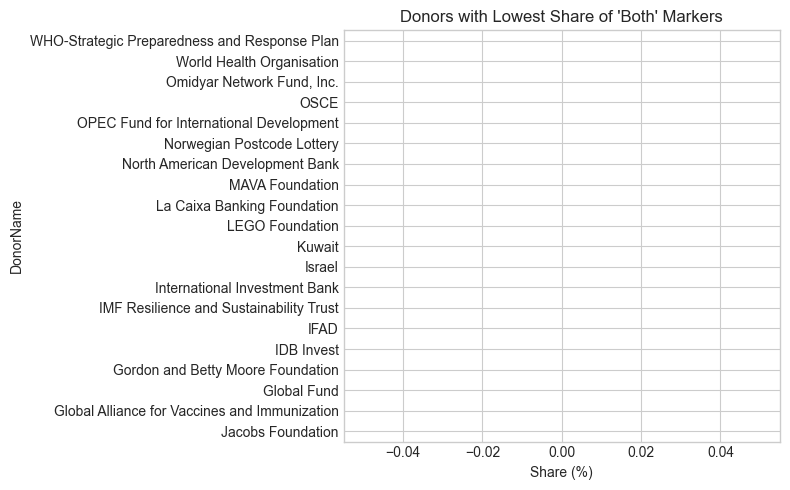

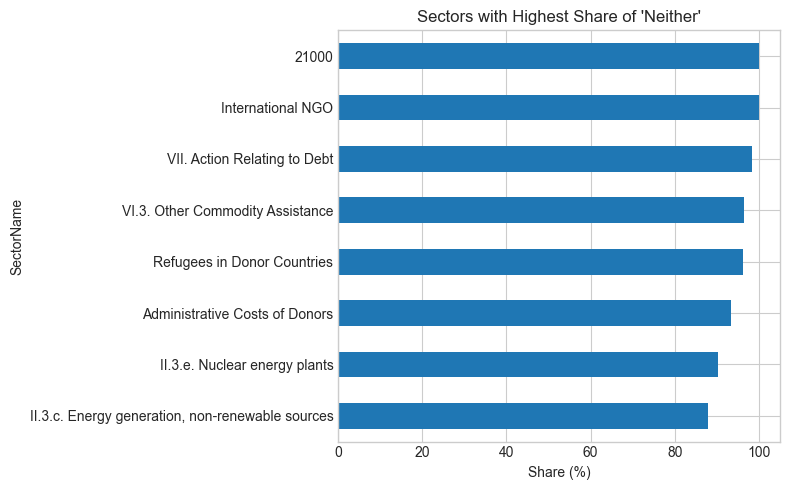

In [46]:
#distribution by sector
sector_bucket = (project_year_donor
                 .groupby(["SectorName","Bucket"])
                 .size().unstack(fill_value=0))
sector_bucket["total"] = sector_bucket.sum(axis=1)
sector_share = sector_bucket.div(sector_bucket["total"], axis=0)

sector_dev = sector_share[buckets].sub(global_dist, axis=1)

###
def plot_top20(series, title, xlabel="Share"):
    s = series.dropna().head(20)
    ax = (s*100).plot(kind="barh", figsize=(8,5))
    ax.set_title(title); ax.set_xlabel(xlabel + " (%)")
    plt.tight_layout(); plt.show()

# Donors lowest on integration ("Both")
plot_top20(donor_share.sort_values("Both").head(20)["Both"],
           "Donors with Lowest Share of 'Both' Markers")

# Sectors highest on 'Neither'
plot_top20(sector_share.sort_values("Neither", ascending=True).tail(20)["Neither"],
           "Sectors with Highest Share of 'Neither'")

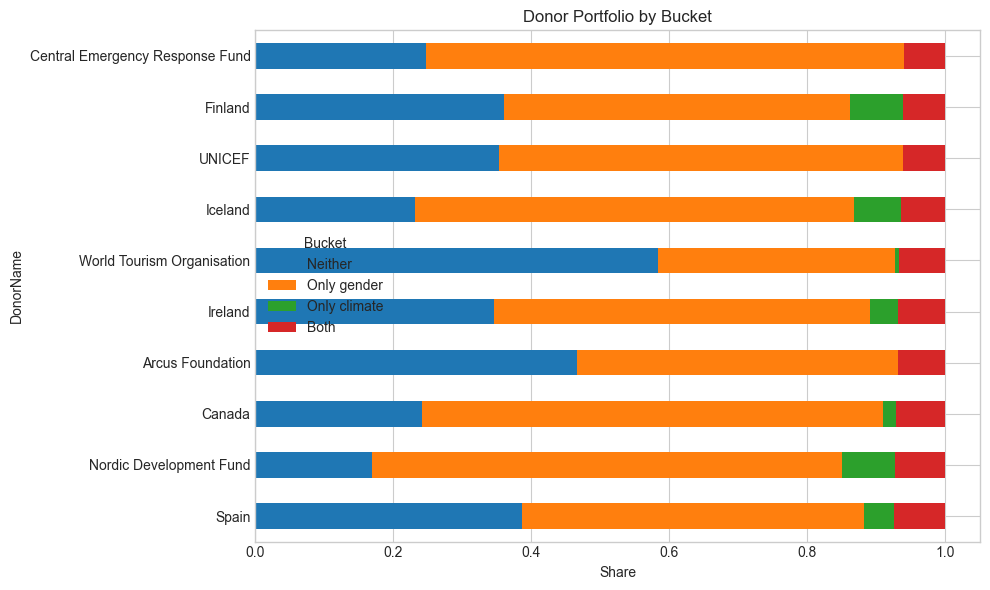

In [47]:
top_don = donor_share.sort_values("Both", ascending=False).head(10)
(top_don[buckets]
 .plot(kind="barh", stacked=True, figsize=(10,6)))
plt.xlabel("Share"); plt.title("Donor Portfolio by Bucket"); plt.tight_layout(); plt.show()

**DOES THE SAME PROJECT HAVE DIFFERENT MARKERS ACROSS DONORS,RECIPIENTS,SECTORS**

In [48]:
# Identify projects that have more than one row
dup_projects = (
    project_year_donor.groupby("ProjectNumber")
    .size()
    .loc[lambda x: x > 1]
    .index
)

multi_df = project_year_donor[project_year_donor["ProjectNumber"].isin(dup_projects)]

In [49]:
multi_df.head(5)

,ProjectNumber,Year,DonorName,SectorName,RecipientName,Gender,ClimateMitigation,ClimateAdaptation,Bucket
0,6607565,2014.0,Germany,I.5.a. Government & Civil Society-general,Tunisia,1.0,0.0,0.0,Only gender
1,6607567,2014.0,Germany,VIII.2. Reconstruction Relief & Rehabilitation,Afghanistan,1.0,0.0,0.0,Only gender
2,6607568,2014.0,Germany,I.1.d. Post-Secondary Education,"Bilateral, unspecified",0.0,0.0,0.0,Neither
3,6607570,2014.0,Germany,II.3.a. Energy Policy,"Bilateral, unspecified",0.0,0.0,0.0,Neither
5,6607573,2014.0,Germany,"I.5.b. Conflict, Peace & Security",Mozambique,1.0,0.0,0.0,Only gender


In [50]:
def check_multi_donor_bucket_inconsistency(
    df: pd.DataFrame,
    project_col="ProjectNumber",
    donor_col="DonorName",
    bucket_col="Bucket",
    min_donors: int = 2,
    export_path: Optional[str] = None
):
    """
    Detect projects reported by multiple donors but with different Bucket values.
    Parameters
    ----------
    df : pd.DataFrame
        DataFrame with at least [project_col, donor_col, bucket_col]
    min_donors : int
        Minimum distinct donors for a project to be considered multi-donor
    export_path : str or None
        If given, export drilldown table to Excel
    Returns
    -------
    dict with:
      summary : overall counts
      inconsistent_projects : per-project table with # donors and # unique buckets
      donor_ranking : donors involved in most inconsistent projects
      drilldown : row-level data for review
    """

    # Count donors per project
    donor_counts = df.groupby(project_col)[donor_col].nunique()
    multi_projects = donor_counts[donor_counts >= min_donors].index

    multi_df = df[df[project_col].isin(multi_projects)].copy()

    # Count unique buckets per project
    bucket_counts = multi_df.groupby(project_col)[bucket_col].nunique()
    inconsistent_projects = bucket_counts[bucket_counts > 1]

    # Drilldown rows for those projects
    drilldown = multi_df[multi_df[project_col].isin(inconsistent_projects.index)]
    drilldown = drilldown[[project_col, donor_col, bucket_col]].sort_values([project_col, donor_col])

    # Donor ranking (how many inconsistent projects each donor is involved in)
    donor_ranking = (
        drilldown.groupby(donor_col)[project_col]
        .nunique()
        .sort_values(ascending=False)
        .rename("n_inconsistent_projects")
        .to_frame()
    )

    summary = pd.DataFrame({
        "multi_donor_projects": [len(multi_projects)],
        "inconsistent_projects": [len(inconsistent_projects)],
        "inconsistent_pct": [round(len(inconsistent_projects)/len(multi_projects)*100, 1)
                             if len(multi_projects)>0 else 0]
    })

    if export_path:
        drilldown.to_excel(export_path, index=False)

    return {
        "summary": summary,
        "inconsistent_projects": inconsistent_projects,
        "donor_ranking": donor_ranking,
        "drilldown": drilldown
    }

In [51]:
results = check_multi_donor_bucket_inconsistency(project_year_donor)

print("=== Summary ===")
print(results["summary"])

print("\n=== Donors with most inconsistent projects ===")
print(results["donor_ranking"].head(10))

print("\n=== Sample Drilldown ===")
print(results["drilldown"].head(20))

=== Summary ===
   multi_donor_projects  inconsistent_projects  inconsistent_pct
0                  9873                   5250              53.2

=== Donors with most inconsistent projects ===
                             n_inconsistent_projects
DonorName                                           
Belgium                                         1648
Global Environment Facility                     1063
Luxembourg                                      1035
Hungary                                         1034
Italy                                            824
Saudi Arabia                                     806
UNDP                                             680
Canada                                           665
Mastercard Foundation                            525
Sweden                                           367

=== Sample Drilldown ===
        ProjectNumber                                      DonorName  \
368702              -                                         France   


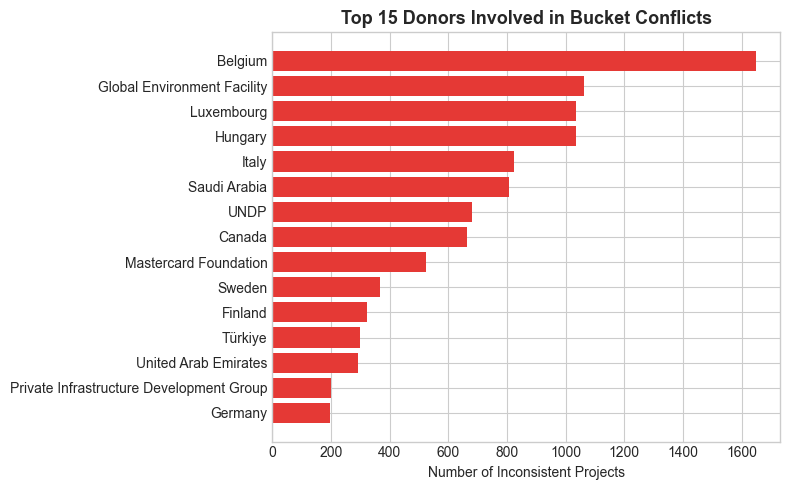

In [52]:
donor_rank = results["donor_ranking"].head(15)

fig, ax = plt.subplots(figsize=(8,5))
ax.barh(donor_rank.index, donor_rank["n_inconsistent_projects"], color="#E53935")
ax.set_xlabel("Number of Inconsistent Projects")
ax.set_title("Top 15 Donors Involved in Bucket Conflicts", fontsize=13, weight="bold")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

In [53]:
project_year_donor[project_year_donor['DonorName']=='Belgium']

,ProjectNumber,Year,DonorName,SectorName,RecipientName,Gender,ClimateMitigation,ClimateAdaptation,Bucket
7,3008662,2014.0,Belgium,IX. Unallocated / Unspecified,"Bilateral, unspecified",1.0,0.0,0.0,Only gender
39,3010653,2014.0,Belgium,"I.1.a. Education, Level Unspecified",Democratic Republic of the Congo,0.0,0.0,0.0,Neither
59,3010407,2014.0,Belgium,I.5.a. Government & Civil Society-general,Mali,0.0,0.0,0.0,Neither
64,3010669,2014.0,Belgium,IV.2. Other Multisector,Democratic Republic of the Congo,0.0,0.0,0.0,Neither
74,3010675,2014.0,Belgium,"I.1.a. Education, Level Unspecified",Democratic Republic of the Congo,0.0,0.0,0.0,Neither
...,...,...,...,...,...,...,...,...,...
1910423,4036,2023.0,Belgium,I.5.a. Government & Civil Society-general,Senegal,2.0,2.0,2.0,Only gender
1911702,3009924,2023.0,Belgium,IV.2. Other Multisector,"Bilateral, unspecified",0.0,0.0,0.0,Neither
1911703,3011463,2023.0,Belgium,IX. Unallocated / Unspecified,Ukraine,0.0,0.0,0.0,Neither
1911713,2395,2023.0,Belgium,II.1. Transport & Storage,Morocco,1.0,0.0,0.0,Only gender


In [54]:
project_year_donor[project_year_donor['ProjectNumber']=='3010653']

,ProjectNumber,Year,DonorName,SectorName,RecipientName,Gender,ClimateMitigation,ClimateAdaptation,Bucket
39,3010653,2014.0,Belgium,"I.1.a. Education, Level Unspecified",Democratic Republic of the Congo,0.0,0.0,0.0,Neither


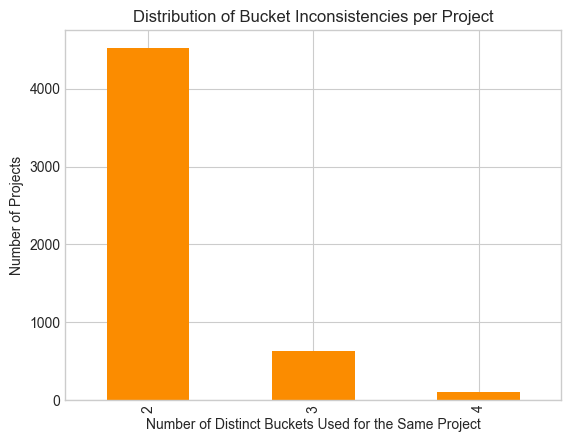

In [55]:
bucket_counts = results["inconsistent_projects"].value_counts()
fig, ax = plt.subplots()
bucket_counts.plot(kind="bar", ax=ax, color="#FB8C00")
ax.set_xlabel("Number of Distinct Buckets Used for the Same Project")
ax.set_ylabel("Number of Projects")
ax.set_title("Distribution of Bucket Inconsistencies per Project")
plt.show()

In [56]:
results['drilldown']['ProjectNumber'].unique()

['-', '0', '00054347', '00070497', '00071131', ..., 'TA9690-REG', 'TA9772-REG', 'TA9911-REG', 'n.a.', 'na']
Length: 5250
Categories (955626, object): [''020B10', ''035C01', ''045L01', ''045L02', ..., 'ÄTH 12-01', 'ÄTH 12-02', 'ÄTH 14-01', '– IFS-RRM/2014/354-176']

In [57]:
project_year_donor[project_year_donor['ProjectNumber']=='TA9772-REG']

,ProjectNumber,Year,DonorName,SectorName,RecipientName,Gender,ClimateMitigation,ClimateAdaptation,Bucket
996456,TA9772-REG,2019.0,Asian Development Bank,II.3.a. Energy Policy,"Oceania, regional",0.0,<NA>,<NA>,Neither
996457,TA9772-REG,2019.0,Asian Development Bank,"II.3.b. Energy generation, renewable sources","Oceania, regional",0.0,<NA>,<NA>,Neither
996458,TA9772-REG,2019.0,Asian Development Bank,II.3.f. Energy distribution,"Oceania, regional",0.0,<NA>,<NA>,Neither
1054992,TA9772-REG,2019.0,Climate Investment Funds,II.3.a. Energy Policy,"Oceania, regional",<NA>,<NA>,<NA>,Neither
1054993,TA9772-REG,2019.0,Climate Investment Funds,"II.3.b. Energy generation, renewable sources","Oceania, regional",<NA>,<NA>,<NA>,Neither
1054994,TA9772-REG,2019.0,Climate Investment Funds,II.3.f. Energy distribution,"Oceania, regional",<NA>,<NA>,<NA>,Neither
1231632,TA9772-REG,2020.0,Asian Development Bank,II.3.a. Energy Policy,"Oceania, regional",1.0,<NA>,<NA>,Only gender
1231633,TA9772-REG,2020.0,Asian Development Bank,"II.3.b. Energy generation, renewable sources","Oceania, regional",1.0,<NA>,<NA>,Only gender
1231634,TA9772-REG,2020.0,Asian Development Bank,II.3.f. Energy distribution,"Oceania, regional",1.0,<NA>,<NA>,Only gender
1351413,TA9772-REG,2021.0,Asian Development Bank,II.3.a. Energy Policy,"Oceania, regional",1.0,<NA>,<NA>,Only gender


In [58]:
def analyze_project_year_changes_bucket_simple(
    df: pd.DataFrame,
    project_col: str = "ProjectNumber",
    year_col: str = "Year",
    bucket_col: str = "Bucket",
    min_years: int = 2,   # require ≥2 years observed to assess change
):
    """
    Year-to-year transitions per project using an already-standardized Bucket column.
    - One record per (project, year) via mode (fallback: first)
    - Counts consecutive-year changes and summarizes stability
    - Minimal, no mapping/normalization (only .str.strip())

    Returns dict with:
      project_change_summary : per-project metrics
      change_transitions     : frequency of consecutive transitions (e.g., 'Neither→Both')
      per_project_year       : collapsed table (project, year, bucket)
    """
    # Keep only needed columns; trim whitespace in Bucket
    use = df[[project_col, year_col, bucket_col]].copy()
    use[bucket_col] = use[bucket_col].astype("string").str.strip()

    # Ensure Year is sortable numeric
    use[year_col] = pd.to_numeric(use[year_col], errors="coerce")
    use = use.dropna(subset=[project_col, year_col])  # guard against bad years

    # Collapse to one bucket per (project, year): mode or first
    def _mode_or_first(x):
        m = x.mode()
        return m.iat[0] if not m.empty else x.iloc[0]

    one_py = (use.groupby([project_col, year_col], observed=True)[bucket_col]
                 .apply(_mode_or_first)
                 .reset_index())

    if one_py.empty:
        return {
            "project_change_summary": pd.DataFrame(),
            "change_transitions": pd.DataFrame(columns=["transition","n"]),
            "per_project_year": one_py,
            "note": "No usable (project, year) rows after collapsing."
        }

    # Keep projects with at least min_years AFTER collapsing
    proj_counts = one_py.groupby(project_col, observed=True)[year_col].nunique()
    valid_projects = proj_counts[proj_counts >= min_years].index
    one_py = one_py[one_py[project_col].isin(valid_projects)].copy()

    if one_py.empty:
        return {
            "project_change_summary": pd.DataFrame(),
            "change_transitions": pd.DataFrame(columns=["transition","n"]),
            "per_project_year": pd.DataFrame(),
            "note": f"No projects have ≥{min_years} years after collapsing."
        }

    # Per-project transitions & summary
    def _transitions(g):
        g = g.sort_values(year_col)
        b = g[bucket_col].tolist()
        y = g[year_col].tolist()
        n_changes = sum(a != c for a, c in zip(b[:-1], b[1:]))
        trans = [f"{a}→{c}" for a, c in zip(b[:-1], b[1:])]
        return pd.Series({
            "years_observed": len(b),
            "n_changes": n_changes,
            "first_year": y[0], "last_year": y[-1],
            "first_bucket": b[0], "last_bucket": b[-1],
            "first_to_last": f"{b[0]}→{b[-1]}",
            "is_stable": int(n_changes == 0),
            "transitions_list": "; ".join(trans)
        })

    project_change_summary = (
        one_py.groupby(project_col, observed=True)
              .apply(_transitions)
              .reset_index()
              .sort_values(["n_changes","years_observed"], ascending=[False, False])
    )

    # Aggregate transition types across all projects (consecutive steps only)
    steps = []
    for _, g in one_py.groupby(project_col, observed=True):
        g = g.sort_values(year_col)
        steps.extend([f"{a}→{c}" for a, c in zip(g[bucket_col].tolist()[:-1],
                                                 g[bucket_col].tolist()[1:])])
    change_transitions = (pd.Series(steps)
                          .value_counts()
                          .rename_axis("transition")
                          .reset_index(name="n"))

    return {
        "project_change_summary": project_change_summary,
        "change_transitions": change_transitions,
        "per_project_year": one_py
    }

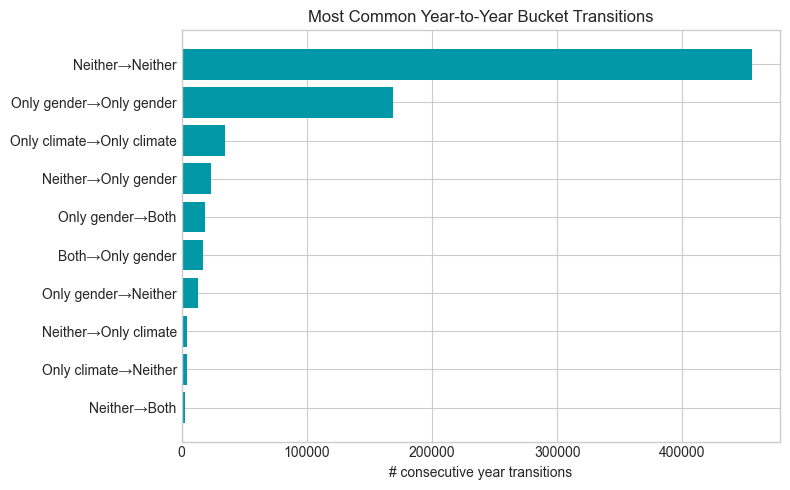

In [59]:
out = analyze_project_year_changes_bucket_simple(project_year_donor)

# Top 10 projects by number of changes
out["project_change_summary"].head(10)

# Plot most common transitions
trans = out["change_transitions"].head(10)
plt.figure(figsize=(8,5))
plt.barh(trans["transition"], trans["n"], color="#0097A7")
plt.gca().invert_yaxis()
plt.xlabel("# consecutive year transitions")
plt.title("Most Common Year-to-Year Bucket Transitions")
plt.tight_layout(); plt.show()

## MISSING MARKERS

In [60]:
def analyze_neither_share(project_year_donor,
                          group_col="DonorName",
                          bucket_col="Bucket",
                          top_n=10,
                          plot=True):

    # --- Compute counts & shares ---
    counts = (project_year_donor.groupby([group_col, bucket_col])
              .size().unstack(fill_value=0))
    counts["total"] = counts.sum(axis=1)
    if "Neither" not in counts.columns:
        counts["Neither"] = 0  # in case group has no 'Neither'
    counts["share_neither"] = counts["Neither"] / counts["total"] * 100

    result = counts[["total", "Neither", "share_neither"]].sort_values(
        "share_neither", ascending=False)

    # --- Global benchmark ---
    global_neither = (project_year_donor[bucket_col]
                      .value_counts(normalize=True)
                      .get("Neither", 0) * 100)

    if plot:
        top_groups = result.head(top_n)
        fig, ax = plt.subplots(figsize=(8, 5))
        bars = ax.barh(top_groups.index, top_groups["share_neither"], color="#BDBDBD")

        # Add % + n labels
        for bar, pct, n in zip(bars, top_groups["share_neither"], top_groups["total"]):
            ax.text(pct + 1, bar.get_y() + bar.get_height()/2,
                    f"{pct:.1f}%  | n={n:,}", va="center", fontsize=8)

        ax.axvline(global_neither, color="red", linestyle="--", label="Global Avg")
        ax.set_xlabel("% of Projects in 'Neither'", fontsize=12)
        ax.set_title(f"Top {top_n} {group_col}s by 'Neither' Share", fontsize=13, weight="bold")
        ax.legend()
        plt.tight_layout()
        plt.show()

    return result, global_neither


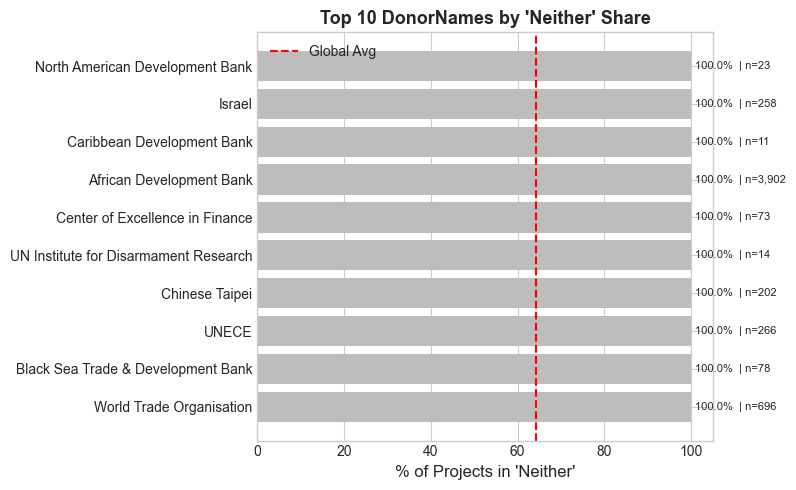

In [61]:
# Donor-level missingness
donor_neither, global_donor = analyze_neither_share(project_year_donor, group_col="DonorName")

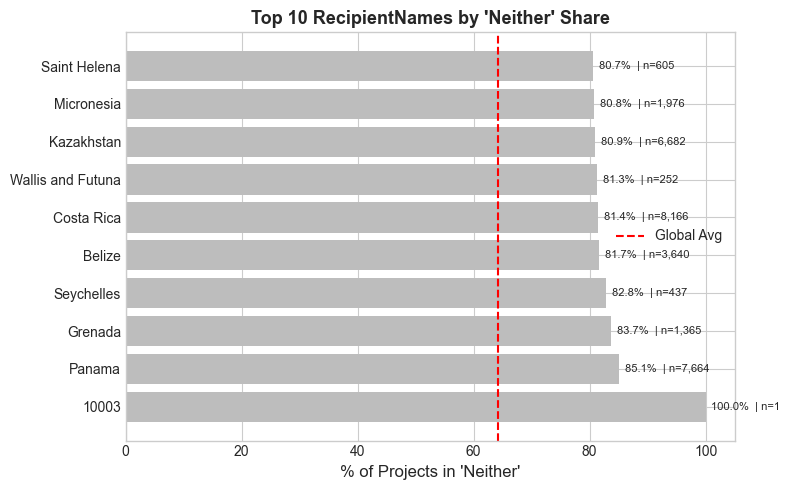

In [62]:
# Country-level missingness
country_neither, global_country = analyze_neither_share(project_year_donor, group_col="RecipientName")

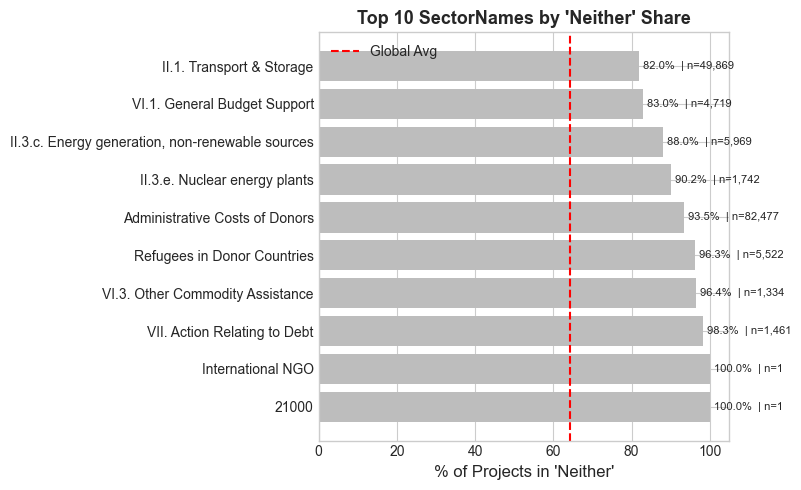

In [63]:
# Sector-level missingness
sector_neither, global_sector = analyze_neither_share(project_year_donor, group_col="SectorName")

## Gender vs Climate Imbalance Index per donor
- Are donors systematically favoring Gender over Climate (or vice versa)

In [64]:
buckets

['Neither', 'Only gender', 'Only climate', 'Both']

In [65]:
BUCKETS = buckets

def classify_donor_exclusivity(df, donor_col="DonorName", bucket_col="Bucket", min_projects=10):
    """
    Classify donors by exclusive use of Gender only, Climate only, or Both.
    Returns:
      - summary table with shares per donor
      - filtered tables for each exclusivity group
    """
    counts = (df.groupby([donor_col, bucket_col])
                .size()
                .unstack(fill_value=0)
                .reindex(columns=BUCKETS, fill_value=0))

    counts["total"] = counts.sum(axis=1)
    counts = counts[counts["total"] >= min_projects]  # filter very small donors

    # compute shares
    shares = counts.div(counts["total"], axis=0)

    # classify exclusivity
    shares["exclusive_group"] = "Mixed"
    shares.loc[(shares["Only gender"] == 1) & (shares["Both"] == 0) & (shares["Only climate"] == 0),
               "exclusive_group"] = "Gender only exclusive"
    shares.loc[(shares["Only climate"] == 1) & (shares["Both"] == 0) & (shares["Only gender"] == 0),
               "exclusive_group"] = "Climate only exclusive"
    shares.loc[(shares["Both"] == 1) & (shares["Only gender"] == 0) & (shares["Only climate"] == 0),
               "exclusive_group"] = "Both exclusive"

    # split for easy plotting
    gender_exclusive = shares[shares["exclusive_group"] == "Gender only exclusive"]
    climate_exclusive = shares[shares["exclusive_group"] == "Climate only exclusive"]
    both_exclusive = shares[shares["exclusive_group"] == "Both exclusive"]

    return {
        "all_donors": shares.sort_values("exclusive_group"),
        "gender_exclusive": gender_exclusive,
        "climate_exclusive": climate_exclusive,
        "both_exclusive": both_exclusive
    }


In [66]:
def plot_exclusive_donors(classified, top_n=15):
    fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

    for ax, (group_name, df, color) in zip(
        axes,
        [
            ("Gender only exclusive", classified["gender_exclusive"], "#E91E63"),
            ("Climate only exclusive", classified["climate_exclusive"], "#009688"),
            ("Both exclusive", classified["both_exclusive"], "#3F51B5")
        ]
    ):
        if not df.empty:
            df = df.sort_values("total", ascending=False).head(top_n)
            ax.barh(df.index, df["total"], color=color)
            ax.set_title(f"{group_name} (Top {top_n})", fontsize=12)
            ax.set_xlabel("# Projects")
            ax.invert_yaxis()
        else:
            ax.set_title(f"{group_name}\n(no donors found)", fontsize=12)
            ax.set_axis_off()

    fig.suptitle("Donors with Exclusive Marker Use", fontsize=14, weight="bold")
    plt.tight_layout()
    plt.show()


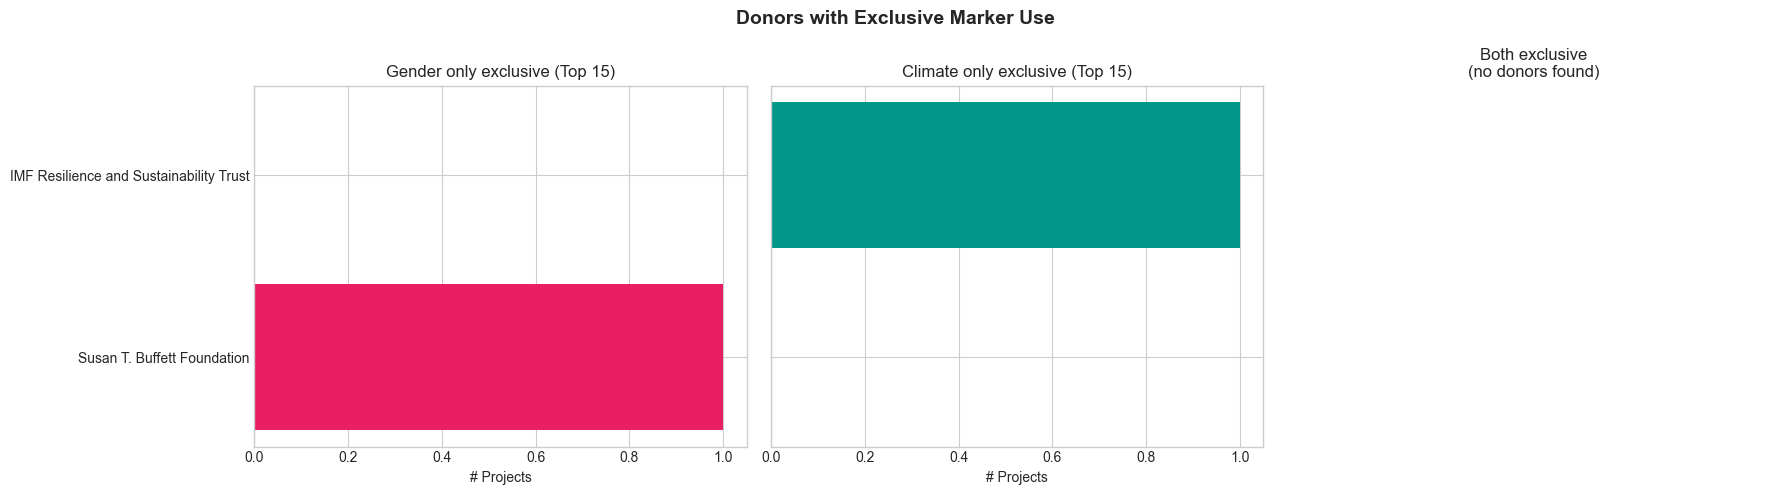

Gender-exclusive donors:


Bucket,total
DonorName,
Susan T. Buffett Foundation,1.0


Climate-exclusive donors:


Bucket,total
DonorName,
IMF Resilience and Sustainability Trust,1.0


Both-exclusive donors:


Bucket,total
DonorName,


In [67]:
classified = classify_donor_exclusivity(project_year_donor, min_projects=20)
plot_exclusive_donors(classified, top_n=15)

print("Gender-exclusive donors:")
display(classified["gender_exclusive"][["total"]])

print("Climate-exclusive donors:")
display(classified["climate_exclusive"][["total"]])

print("Both-exclusive donors:")
display(classified["both_exclusive"][["total"]])


## Consistency Across Sectors
- Are some donors applying markers in some sectors but not others?

In [68]:
def donor_sector_heatmap_annotated(
    df: pd.DataFrame,
    donor_col: str = "DonorName",
    sector_col: str = "SectorName",
    bucket_col: str = "Bucket",
    value: str = "Neither",            # which bucket to visualize
    top_donors: int = 20,
    top_sectors: int = 20,
    min_n_cell: int = 10,              # only annotate cells with at least this many projects
    figsize=(min(18, 1_000/60), 9),    # width auto-limited for readability
    cmap: str = "Reds"
):
    """
    Heatmap of % projects in `value` bucket by Donor × Sector with annotations:
      - cell text: "XX%\\n(n=YY)" for cells with n >= min_n_cell; blank otherwise
    Rows/cols are sorted by their mean share so the worst offenders rise to the top.
    """

    # 1) totals and bucket counts
    totals = (df.groupby([donor_col, sector_col]).size().rename("n_total"))
    hits = (df[df[bucket_col] == value]
            .groupby([donor_col, sector_col]).size()
            .rename("n_value"))

    tab = (pd.concat([totals, hits], axis=1)
             .fillna(0)
             .astype({"n_total":"int64", "n_value":"int64"}))
    tab["share"] = tab["n_value"] / tab["n_total"]  # 0–1

    # 2) pick top donors/sectors by *volume* to keep the figure readable
    d_keep = (tab.groupby(level=0)["n_total"].sum()
                .sort_values(ascending=False).head(top_donors).index)
    s_keep = (tab.groupby(level=1)["n_total"].sum()
                .sort_values(ascending=False).head(top_sectors).index)
    tab = tab.loc[(tab.index.get_level_values(0).isin(d_keep)) &
                  (tab.index.get_level_values(1).isin(s_keep))]

    # 3) wide matrices
    share_mat = (tab["share"].unstack(sector_col).reindex(index=d_keep, columns=s_keep).fillna(0.0))
    n_mat     = (tab["n_total"].unstack(sector_col).reindex(index=d_keep, columns=s_keep).fillna(0).astype(int))

    # 4) sort rows & cols by mean share (descending) so darkest move to top-left
    row_order = share_mat.mean(axis=1).sort_values(ascending=False).index
    col_order = share_mat.mean(axis=0).sort_values(ascending=False).index
    share_mat = share_mat.loc[row_order, col_order]
    n_mat     = n_mat.loc[row_order, col_order]

    # 5) annotation strings: percentage + n (only if n >= min_n_cell)
    pct = (share_mat * 100).round(0).astype(int).astype(str) + "%"
    annot = pct.mask(n_mat < min_n_cell, "") + np.where(n_mat < min_n_cell, "", "\n(n=" + n_mat.astype(str) + ")")

    # 6) plot
    plt.figure(figsize=figsize)
    ax = sns.heatmap(
        share_mat * 100,
        cmap=cmap,
        annot=annot,
        fmt="",
        linewidths=0.3,
        linecolor="white",
        cbar_kws={"label": f"% {value}"},
        annot_kws={"fontsize": 8}
    )
    ax.set_title(f"{value} Share by Donor × Sector", fontsize=13, weight="bold")
    ax.set_xlabel("Sector")
    ax.set_ylabel("Donor")
    plt.xticks(rotation=60, ha="right")
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()

    return share_mat, n_mat

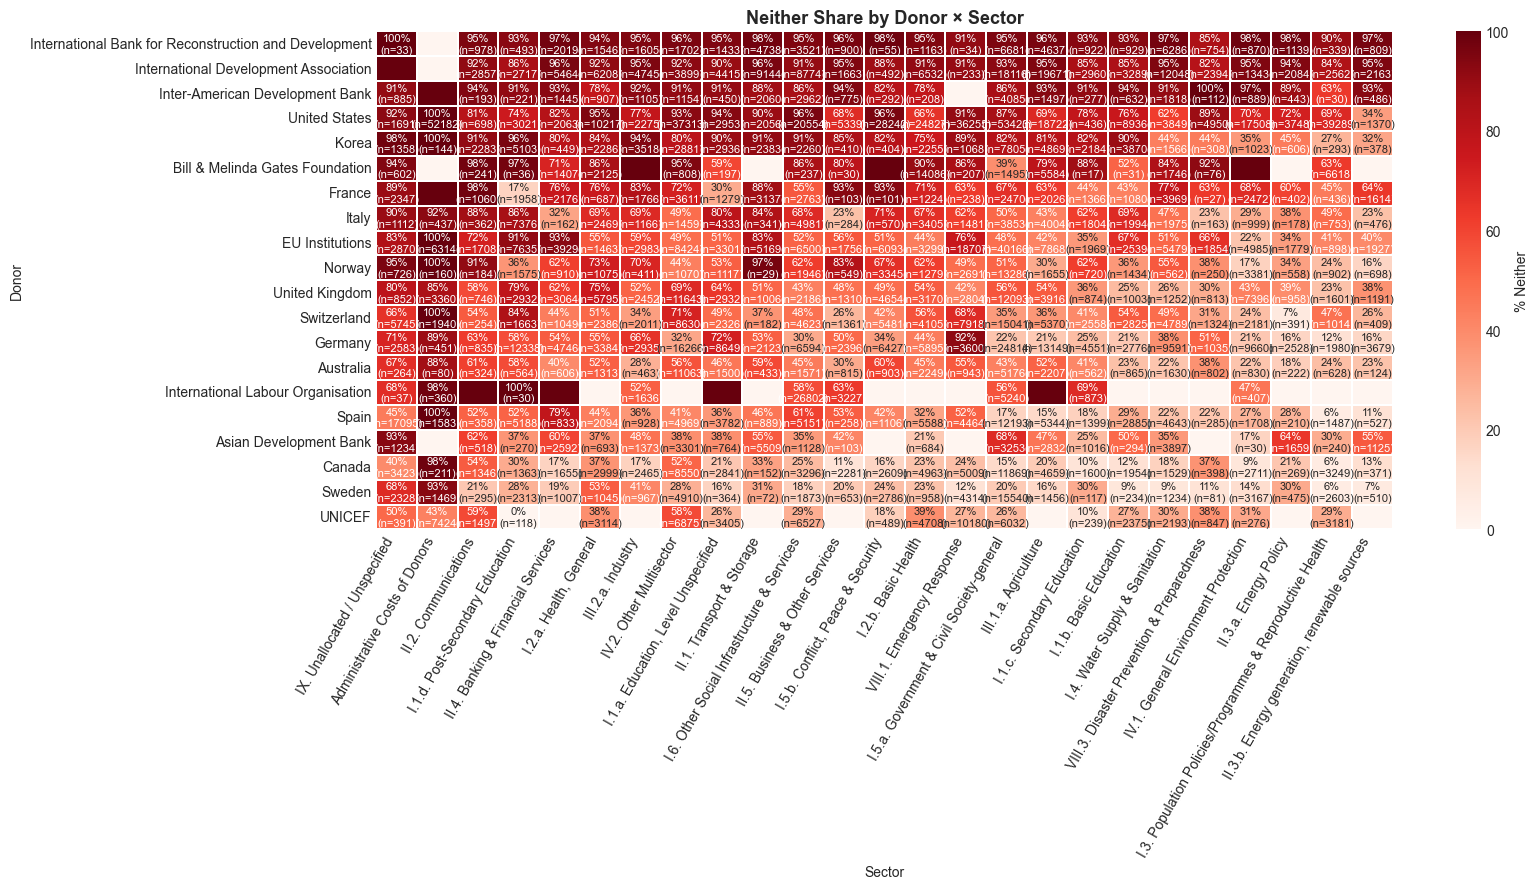

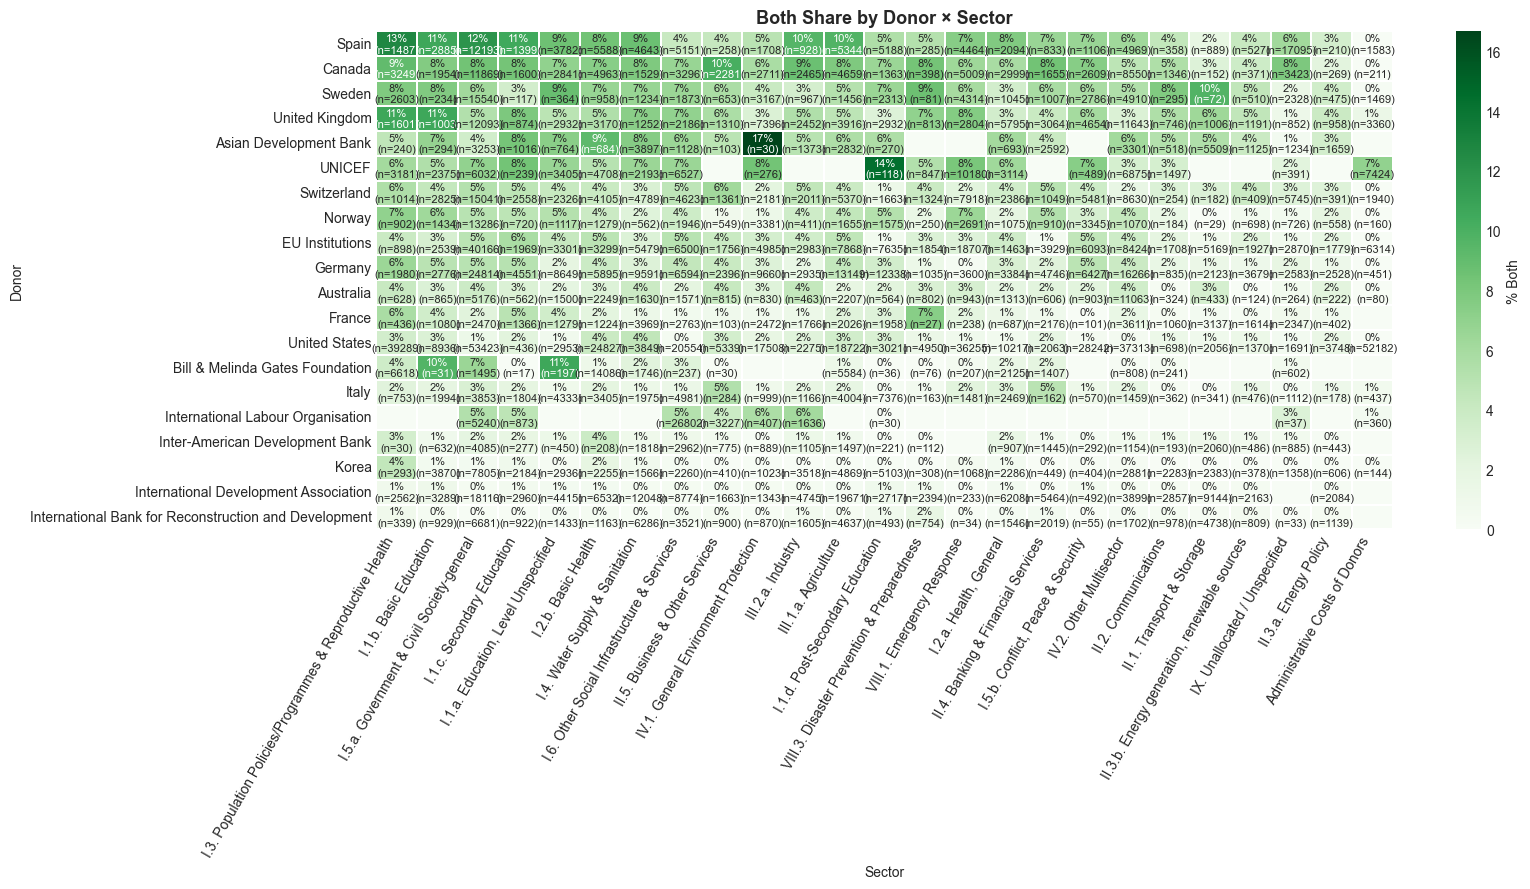

In [69]:
# Most common QC view: % 'Neither' with annotations
share_mat, n_mat = donor_sector_heatmap_annotated(
    project_year_donor, value="Neither", top_donors=20, top_sectors=25, min_n_cell=15
)

# Or look at integration:
share_both, n_both = donor_sector_heatmap_annotated(
    project_year_donor, value="Both", top_donors=20, top_sectors=25, min_n_cell=15, cmap="Greens"
)


## PORTFOLIO DIVERSITY
- Are donors concentrated in one bucket or evenly spread?

In [70]:
def donor_bucket_entropy(project_year_donor):
    share = (project_year_donor.groupby(["DonorName","Bucket"])
             .size().unstack(fill_value=0))
    p = share.div(share.sum(axis=1), axis=0)

    def entropy(row):
        q = row[row>0].values
        return float(-(q * np.log2(q)).sum()) if q.size else np.nan

    p["entropy"] = p.apply(entropy, axis=1)
    # higher = more balanced across buckets; lower = concentrated
    return p[["entropy"]].sort_values("entropy", ascending=False)

donor_entropy = donor_bucket_entropy(project_year_donor); donor_entropy.head(10)


Bucket,entropy
DonorName,
Children's Investment Fund Foundation,1.772170
William and Flora Hewlett Foundation,1.681723
Food and Agriculture Organisation,1.621834
Dutch Postcode Lottery,1.580705
Germany,1.569055
Finland,1.563090
Norway,1.562209
Australia,1.556595
David and Lucile Packard Foundation,1.546352


## How do donors cluster based on bucket profiles?

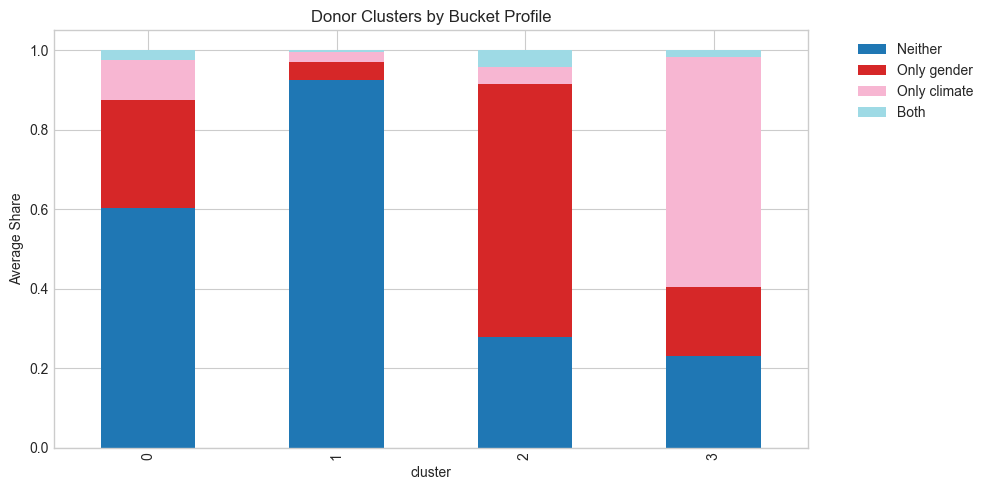

In [71]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import normalize
import pandas as pd
import matplotlib.pyplot as plt

BUCKETS = buckets

def cluster_donors_by_bucket(df, donor_col="DonorName", bucket_col="Bucket", n_clusters=4, min_projects=20):
    # donor x bucket counts
    counts = (df.groupby([donor_col, bucket_col])
                .size()
                .unstack(fill_value=0)
                .reindex(columns=BUCKETS, fill_value=0))
    counts["n_projects"] = counts.sum(axis=1)
    counts = counts[counts["n_projects"] >= min_projects]

    # convert to share profiles
    profiles = counts[BUCKETS].div(counts["n_projects"], axis=0)

    # clustering
    km = KMeans(n_clusters=n_clusters, random_state=42, n_init="auto")
    labels = km.fit_predict(profiles)

    profiles["cluster"] = labels
    return profiles, km

profiles, km_model = cluster_donors_by_bucket(project_year_donor)

# visualize cluster profiles as stacked bars
cluster_profiles = profiles.groupby("cluster")[BUCKETS].mean()

cluster_profiles.plot(kind="bar", stacked=True, figsize=(10, 5), colormap="tab20")
plt.ylabel("Average Share")
plt.title("Donor Clusters by Bucket Profile")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

“Donors cluster into four distinct groups based on their marker use profiles:

Marker-Absent Donors (Cluster 1): Rarely apply gender or climate markers.

Neither-Heavy Donors (Cluster 0): Apply some markers, but mostly leave projects unmarked.

Gender-Focused Donors (Cluster 2): Report Gender-only more frequently, but have very low climate integration.

Climate-Focused Donors (Cluster 3): Systematically report Climate-only, sometimes ignoring gender.”

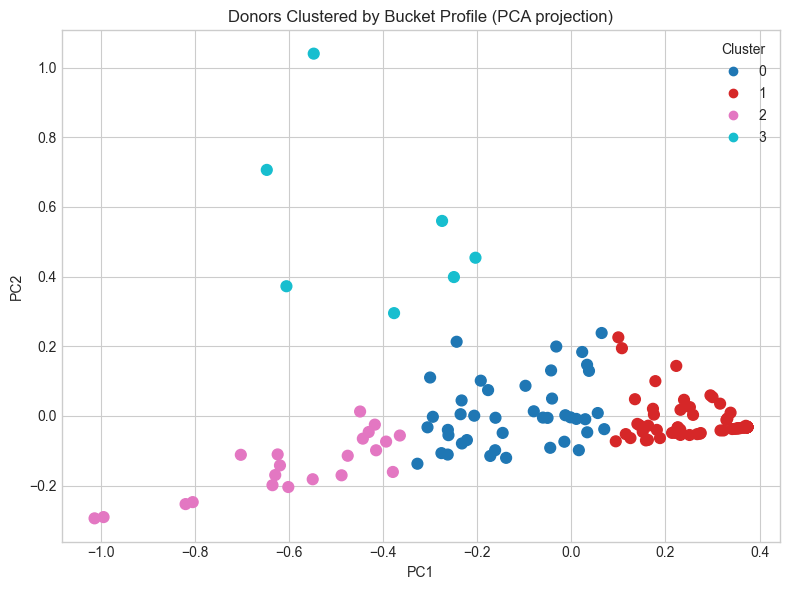

In [72]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
coords = pca.fit_transform(profiles[BUCKETS])

plt.figure(figsize=(8, 6))
scatter = plt.scatter(coords[:, 0], coords[:, 1], c=profiles["cluster"], cmap="tab10", s=60)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Donors Clustered by Bucket Profile (PCA projection)")
plt.legend(*scatter.legend_elements(), title="Cluster")
plt.tight_layout()
plt.show()

## TEXT VALIDATIONS - USING ONLY PROJECT UNDER 'BOTH' BUCKET

In [73]:
crs_data.head()

,Year,DonorCode,DEDonorcode,DonorName,AgencyCode,AgencyName,CrsID,ProjectNumber,InitialReport,RecipientCode,DERecipientcode,RecipientName,RegionCode,DERegioncode,RegionName,IncomegroupCode,DEIncomegroupCode,IncomegroupName,FlowCode,FlowName,Bi_Multi,Category,Finance_T,Aid_T,USD_Commitment,USD_Disbursement,USD_Received,USD_AmountUntied,USD_AmountPartialTied,USD_AmountTied,CurrencyCode,Commitment_National,Disbursement_National,GrantEquiv,ShortDescription,ProjectTitle,PurposeCode,PurposeName,SectorCode,SectorName,ChannelCode,ChannelName,ChannelReportedName,ExpectedStartDate,CompletionDate,LongDescription,SDGfocus,Gender,Environment,DIG,RMNCH,Biodiversity,ClimateMitigation,ClimateAdaptation,Desertification,CommitmentDate,Bucket
0,2014.0,5,DEU,Germany,7.0,Federal Foreign Office,2014008560,6607565,8.0,139,TUN,Tunisia,10002,F4,North of Sahara,10018,LMIC,LMICs,11,ODA Grants,1.0,10.0,110,C01,0.161292,0.161292,0.0,0.0,NaN,0.161292,302.0,0.161292,0.161292,NaN,STRENGTHENING OF LEGAL AID SERVICES,Strengthening of legal aid services,15130,Legal and judicial development,151,I.5.a. Government & Civil Society-general,22000.0,Donor country-based NGO,Donor country-based NGO,2014-08-15,2014-12-31,Provide criminal defense services to indigent ...,NaN,1,0,2,0,0,0,0,0.0,2014-08-15,Only gender
1,2014.0,5,DEU,Germany,7.0,Federal Foreign Office,2014008562,6607567,1.0,625,AFG,Afghanistan,10009,S4_S7,South & Central Asia,10016,LDC,LDCs,11,ODA Grants,1.0,10.0,110,C01,4.385697,1.953164,0.0,4.385697,NaN,0.0,302.0,4.385697,1.953164,NaN,NaN,NaN,73010,Immediate post-emergency reconstruction and re...,730,VIII.2. Reconstruction Relief & Rehabilitation,90000.0,Other,Other,2014-08-01,2014-12-31,NaN,NaN,1,1,2,0,0,0,0,0.0,2014-08-01,Only gender
2,2014.0,5,DEU,Germany,7.0,Federal Foreign Office,2014008563,6607568,1.0,9998,DPGC_X,"Bilateral, unspecified",15006,DPGC_X,Regional and Unspecified,10024,INC_X,Part I unallocated by income,11,ODA Grants,1.0,10.0,110,E01,0.690275,0.105570,0.0,0.0,NaN,0.690275,302.0,0.690275,0.105570,NaN,SCHOLARSHIPS FOR FOREIGN STUDENTS,Scholarships for foreign students,11420,Higher education,114,I.1.d. Post-Secondary Education,22000.0,Donor country-based NGO,Donor country-based NGO,2014-01-01,2014-12-31,"Development of educated classes in society, pr...",NaN,0,0,0,0,0,0,0,0.0,2014-01-01,Neither
3,2014.0,5,DEU,Germany,7.0,Federal Foreign Office,2014008564,6607570,8.0,9998,DPGC_X,"Bilateral, unspecified",15006,DPGC_X,Regional and Unspecified,10024,INC_X,Part I unallocated by income,11,ODA Grants,1.0,10.0,110,C01,0.050500,0.050500,0.0,0.0505,NaN,0.0,302.0,0.050500,0.050500,NaN,POLITICAL PROCESS OF ENERGY TRANSITION,Political process of energy transition,23181,Energy education/training,231,II.3.a. Energy Policy,10000.0,Public Sector Institutions,GIZ,2014-09-01,2014-12-31,Concentrated insight of the international part...,NaN,0,0,0,0,0,0,0,0.0,2014-09-01,Neither
4,2014.0,5,DEU,Germany,7.0,Federal Foreign Office,2014008565,6607571,1.0,9998,DPGC_X,"Bilateral, unspecified",15006,DPGC_X,Regional and Unspecified,10024,INC_X,Part I unallocated by income,11,ODA Grants,1.0,10.0,110,D02,0.023440,0.023121,0.0,0.0,NaN,0.02344,302.0,0.023440,0.023121,NaN,EUROPEAN YOUTH PRESS - RETHINKING JOURNALISM,European Youth Press - Rethinking Journalism,15153,Media and free flow of information,151,I.5.a. Government & Civil Society-general,90000.0,Other,Other,2014-07-01,2014-12-31,Professionalisation of young media professiona...,NaN,1,0,2,0,0,0,0,0.0,2014-07-01,Only gender


In [74]:
crs_data1 = crs_data[crs_data['Bucket']=='Both']

In [75]:
crs_data1.shape

(166336, 57)

In [76]:
def build_project_year_df_minmem(raw_df: pd.DataFrame) -> pd.DataFrame:
    """
    Memory-friendly: one row per (project_id, year, donor, recipient, sector_code, bucket).
    Selects the longest title/description within each group (no big string joins).
    """
    cols_needed = ["ProjectNumber","Year","DonorName","RecipientName","SectorName","Bucket",
                   "ProjectTitle","LongDescription"]
    df = raw_df[cols_needed].copy()

    # Filter early to shrink data (keep only 'both' if that's your analysis)
    if "Bucket" in df.columns:
        df = df[df["Bucket"].astype(str).str.strip().str.lower().eq("both")]

    # Make sure text is object (not categorical) and cleaned
    for col in ["ProjectTitle","LongDescription"]:
        s = df[col]
        if pd.api.types.is_categorical_dtype(s):
            s = s.astype("object")
        df[col] = s.fillna("").astype("object").str.strip()

    # Add lengths once (cheap) and pick the row with max length per group
    df["__tlen"] = df["ProjectTitle"].str.len()
    df["__dlen"] = df["LongDescription"].str.len()

    # To pick the "best" row per group, we rank by (desc_len, title_len)
    # and take the first row in each group (no massive string concatenation).
    df = df.sort_values(["ProjectNumber","Year","DonorName","RecipientName","SectorName","Bucket",
                         "__dlen","__tlen"], ascending=[True,True,True,True,True,True,
                                                       False,False])
    grouped = df.drop_duplicates(subset=["ProjectNumber","Year","DonorName","RecipientName","SectorName","Bucket",])

    # Keep only needed columns
    out = grouped[["ProjectNumber","Year","DonorName","RecipientName","SectorName","Bucket",
                   "ProjectTitle","LongDescription"]].reset_index(drop=True)
    return out

In [77]:
grouped_df = build_project_year_df_minmem(crs_data1)

In [78]:
grouped_df

,ProjectNumber,Year,DonorName,RecipientName,SectorName,Bucket,ProjectTitle,LongDescription
0,001561,2015.0,Portugal,Mozambique,I.1.c. Secondary Education,Both,Local Scholarships,Scholarships to attend secondary school in the...
1,001561,2016.0,Portugal,Mozambique,I.1.c. Secondary Education,Both,Local Scholarships,Scholarships to attend secondary school in the...
2,001561,2017.0,Portugal,Mozambique,I.1.c. Secondary Education,Both,Local Scholarships,Scholarships to attend secondary school in the...
3,001561,2018.0,Portugal,Mozambique,I.1.c. Secondary Education,Both,Local Scholarships,Scholarships to attend higher education in the...
4,001561,2019.0,Portugal,Mozambique,I.1.c. Secondary Education,Both,Local Scholarships,Scholarships to attend higher education in the...
...,...,...,...,...,...,...,...,...
127820,NaN,2023.0,Japan,Zambia,III.1.a. Agriculture,Both,TC AGGREGATED ACTIVITIES,TC AGGREGATED ACTIVITIES
127821,NaN,2023.0,Liechtenstein,Zimbabwe,III.1.a. Agriculture,Both,"Empowering rural women in Chiundura, Thulilish...","Empowering rural women in Chiundura, Thulilish..."
127822,NaN,2023.0,Slovenia,Egypt,III.2.a. Industry,Both,Development of an inclusive and sustainable gl...,Projekt namerava izboljšati dobaviteljsko veri...
127823,NaN,2023.0,Slovenia,Moldova,III.1.b. Forestry,Both,Preparation on cooperation in the field of af...,Priprave na koordinacijski sestanek med MKGP R...


In [79]:
def _to_text(x) -> str:
    # robustly turn anything into a clean string
    if x is None or (isinstance(x, float) and np.isnan(x)):
        return ""
    if isinstance(x, list):
        return " ".join(map(str, x))
    return str(x)

In [ ]:
# ==========================================
# NLP Validation for "Both" Bucket Projects (Year-aware)
# ==========================================
# - Filters rows where bucket == "both"
# - Extracts features from title/description; computes a rule-based substantive score
# - Optional supervised refinement (TF-IDF + Logistic Regression)
# - RETURNS: per-project-year scores + donor/sector summaries INCLUDING YEAR
# - Includes fast_aggregate() helper to build project–year–donor–recipient rows
#
# Required columns in your DataFrame (rename via COLS if different):
#   ProjectNumber, Year, DonorName, SectorName, ProjectTitle, LongDescription, Bucket
# Optional:
#   label_substantive  (0/1; for supervised refinement)
#
# Usage:
#   keys = ["ProjectNumber","Year","DonorName","RecipientName"]  # adjust as available
#   grouped = fast_aggregate(crs_data2, keys)  # build project–year rows
#   out = validate_both_marked(grouped, use_supervised=True)
#   out["scored_projects"].head()

# -----------------------------
# 0) Config: column names / thresholds
# -----------------------------
COLS = {
    "id":    "ProjectNumber",
    "year":  "Year",             
    "sector":"SectorName",
    "title": "ProjectTitle",
    "desc":  "LongDescription",
    "bucket":"Bucket",
    "donor": "DonorName",
    "label": "label_substantive",  # optional
}

THRESH = {
    "min_total_terms_per_1k": 12,
    "min_each_pillar_per_1k": 4,
    "min_spread_sections": 2,
    "min_action_cues": 1,
    "balance_ratio_min": 0.45,
}

# -----------------------------
# 1) Domain lexicons
# -----------------------------
GENDER_TERMS = [
    "gender","women","girls","female","gbv","gender-based violence",
    "women’s empowerment","sex-disaggregated","female farmers","care work",
    "gender mainstreaming","gender analysis","gender budgeting","menstrual",
    "livelihoods for women","vawg","wage gap","women-led","gender norms",
    "intersectionality","shea"
]

CLIMATE_TERMS = [
    "climate","mitigation","adaptation","resilience","resilient","carbon",
    "ghg","emissions","sequestration","renewable","solar","wind",
    "reforestation","afforestation","drought","flood","hazard",
    "vulnerability assessment","early warning","nature-based solutions",
    "ndc","ltr","net zero","paris agreement","energy efficiency",
    "mrv","loss and damage"
]

ACTION_CUES = [
    "pilot","deploy","train","build capacity","capacity building","scale",
    "implement","demonstration","field trial","evaluation","baseline",
    "endline","monitoring","m&e","indicator","kpi","budget","workshop",
    "curriculum","toolkit","guideline","grievance","governance",
    "policy reform","regulation","institutional","community of practice"
]

In [80]:
# -----------------------------
# 2) Helpers
# -----------------------------
_word_re = re.compile(r"[A-Za-z]+(?:['-][A-Za-z]+)?")

def _to_text(x):
    if x is None or (isinstance(x, float) and math.isnan(x)):
        return ""
    if isinstance(x, list):
        return " ".join(map(str, x))
    return str(x)

def _tokenize(text: str) -> List[str]:
    if not isinstance(text, str):
        return []
    return [t.lower() for t in _word_re.findall(text)]

def _count_hits(tokens: List[str], phrases: List[str]) -> int:
    text = " " + " ".join(tokens) + " "
    hits = 0
    for p in phrases:
        p_norm = " " + p.lower().strip() + " "
        hits += text.count(p_norm)
    return hits

def _density_per_1k(n_hits: int, n_tokens: int) -> float:
    if n_tokens == 0:
        return 0.0
    return 1000.0 * n_hits / n_tokens

def _split_sections(desc: str) -> List[str]:
    if not isinstance(desc, str) or not desc.strip():
        return []
    # naive: paragraphs or markdown headings
    return re.split(r"\n{2,}|(?:^|\n)##? +", desc)

def _is_both(val) -> bool:
    if not isinstance(val, str):
        return False
    v = val.strip().lower()
    return v in {"both","gender+climate","gender & climate","gender and climate","g+c","g&c"}

# -----------------------------
# 3) Feature extraction (BUCKET == "both")
# -----------------------------
def features_for_both_marked(df: pd.DataFrame) -> pd.DataFrame:
    cols = COLS

    # filter to "both"
    keep = df[df[cols["bucket"]].astype("string").apply(_is_both)].copy()

    # ensure year column exists (pass-through)
    if cols.get("year") and cols["year"] not in keep.columns:
        keep[cols["year"]] = np.nan

    # text columns to object strings
    keep[cols["title"]] = keep[cols["title"]].map(_to_text).astype("object")
    keep[cols["desc"]]  = keep[cols["desc"]].map(_to_text).astype("object")

    # tokenize
    keep["__title_tokens"] = keep[cols["title"]].apply(_tokenize)
    keep["__desc_tokens"]  = keep[cols["desc"]].apply(_tokenize)
    keep["__n_tokens"] = keep["__title_tokens"].apply(len) + keep["__desc_tokens"].apply(len)

    # raw hits
    keep["g_hits"] = keep["__title_tokens"].apply(lambda t: _count_hits(t, GENDER_TERMS)) \
                   + keep["__desc_tokens"].apply(lambda t: _count_hits(t, GENDER_TERMS))
    keep["c_hits"] = keep["__title_tokens"].apply(lambda t: _count_hits(t, CLIMATE_TERMS)) \
                   + keep["__desc_tokens"].apply(lambda t: _count_hits(t, CLIMATE_TERMS))
    keep["a_hits"] = keep["__title_tokens"].apply(lambda t: _count_hits(t, ACTION_CUES)) \
                   + keep["__desc_tokens"].apply(lambda t: _count_hits(t, ACTION_CUES))

    # densities
    keep["g_density_1k"] = keep.apply(lambda r: _density_per_1k(r["g_hits"], r["__n_tokens"]), axis=1)
    keep["c_density_1k"] = keep.apply(lambda r: _density_per_1k(r["c_hits"], r["__n_tokens"]), axis=1)
    keep["ac_density_1k"] = keep.apply(lambda r: _density_per_1k(r["a_hits"], r["__n_tokens"]), axis=1)
    keep["total_density_1k"] = keep["g_density_1k"] + keep["c_density_1k"]

    # section spread
    def section_spread(row) -> int:
        title_present = int(row["g_hits"] > 0 or row["c_hits"] > 0)
        body_sections = _split_sections(row[cols["desc"]])
        body_present = 0
        if body_sections:
            body_present = sum(
                1 for s in body_sections
                if (_count_hits(_tokenize(s), GENDER_TERMS) + _count_hits(_tokenize(s), CLIMATE_TERMS)) > 0
            )
        return title_present + min(body_present, 3)

    keep["spread_sections"] = keep.apply(section_spread, axis=1)

    # pillar balance
    def balance_ratio(row) -> float:
        g = row["g_density_1k"]; c = row["c_density_1k"]
        hi = max(g, c); lo = min(g, c)
        return 0.0 if hi == 0 else lo / hi

    keep["pillar_balance"] = keep.apply(balance_ratio, axis=1)
    keep["action_strength"] = 1.0 / (1.0 + np.exp(-0.7 * (keep["ac_density_1k"] - 2.0)))

    # composite rule-based score (0..100)
    def rule_score(row) -> float:
        s = 0.0
        if row["total_density_1k"] >= THRESH["min_total_terms_per_1k"]:
            s += 35
        if row["g_density_1k"] >= THRESH["min_each_pillar_per_1k"]:
            s += 15
        if row["c_density_1k"] >= THRESH["min_each_pillar_per_1k"]:
            s += 15
        if row["spread_sections"] >= THRESH["min_spread_sections"]:
            s += 15
        s += 10 * min(1.0, row["pillar_balance"] / THRESH["balance_ratio_min"])
        if row["a_hits"] >= THRESH["min_action_cues"]:
            s += 10
        # slight taper if extremely long text
        s = s * (1.0 - 0.05 * (row["__n_tokens"] > 1200))
        return float(max(0.0, min(100.0, s)))

    keep["substantive_score"] = keep.apply(rule_score, axis=1)
    keep["nlp_label_rule"] = (keep["substantive_score"] >= 60).astype(int)
    return keep

In [ ]:
# 4) Optional supervised refinement
# -----------------------------
def supervised_refinement(keep: pd.DataFrame, text_col="__concat_text") -> Tuple[pd.DataFrame, Dict]:
    from sklearn.model_selection import train_test_split
    from sklearn.feature_extraction.text import TfidfVectorizer
    from sklearn.linear_model import LogisticRegression
    from sklearn.metrics import classification_report

    keep[text_col] = keep[COLS["title"]].fillna("") + " \n " + keep[COLS["desc"]].fillna("")
    if COLS["label"] not in keep.columns:
        return keep, {"note": "No label column present; skipping supervised refinement."}

    labeled = keep.dropna(subset=[COLS["label"]]).copy()
    if labeled.empty or labeled[COLS["label"]].nunique() < 2:
        return keep, {"note": "Insufficient labeled data for supervised refinement."}

    X_train, X_val, y_train, y_val = train_test_split(
        labeled[text_col],
        labeled[COLS["label"]].astype(int),
        test_size=0.25,
        random_state=42,
        stratify=labeled[COLS["label"]]
    )

    tfidf = TfidfVectorizer(ngram_range=(1, 2), min_df=3, max_df=0.9)
    Xtr = tfidf.fit_transform(X_train)
    Xva = tfidf.transform(X_val)

    clf = LogisticRegression(max_iter=200, class_weight="balanced")
    clf.fit(Xtr, y_train)
    yhat = clf.predict(Xva)
    report = classification_report(y_val, yhat, output_dict=True)

    keep["nlp_label_supervised_proba"] = clf.predict_proba(tfidf.transform(keep[text_col]))[:, 1]
    keep["nlp_label_supervised"] = (keep["nlp_label_supervised_proba"] >= 0.5).astype(int)

    return keep, {"val_report": report, "vectorizer": tfidf, "model": clf, "note": "Supervised refinement applied."}


In [ ]:
# -----------------------------
# 5) End-to-end runner (year-aware outputs)
# -----------------------------
def validate_both_marked(df: pd.DataFrame, use_supervised: bool = True) -> Dict[str, pd.DataFrame]:
    keep = features_for_both_marked(df)
    info = {}

    if use_supervised:
        keep, sup_info = supervised_refinement(keep)
        info["supervised_info"] = sup_info
        if "nlp_label_supervised" in keep.columns:
            keep["nlp_label_final"] = np.where(
                (keep["nlp_label_rule"] == 1) & (keep["nlp_label_supervised"] == 1),
                1, 0
            )
        else:
            keep["nlp_label_final"] = keep["nlp_label_rule"]
    else:
        keep["nlp_label_final"] = keep["nlp_label_rule"]
        info["supervised_info"] = {"note": "Supervised refinement disabled."}

    # donor breakdown (all years together)
    donor_view = (keep
        .groupby(COLS["donor"], dropna=False)
        .agg(n_projects=(COLS["id"], "count"),
             pct_substantive=("nlp_label_final", "mean"),
             avg_score=("substantive_score", "mean"),
             med_score=("substantive_score", "median"))
        .reset_index()
        .sort_values(["pct_substantive", "avg_score"], ascending=False)
    )
    donor_view["pct_substantive"] = (100 * donor_view["pct_substantive"]).round(1)

    # donor × sector
    donor_sector_view = (keep
        .groupby([COLS["donor"], COLS["sector"]], dropna=False)
        .agg(n_projects=(COLS["id"], "count"),
             pct_substantive=("nlp_label_final", "mean"),
             avg_score=("substantive_score", "mean"))
        .reset_index()
        .sort_values(["pct_substantive", "avg_score"], ascending=False)
    )
    donor_sector_view["pct_substantive"] = (100 * donor_sector_view["pct_substantive"]).round(1)

    # donor × year
    donor_year_view = (keep
        .groupby([COLS["donor"], COLS["year"]], dropna=False)
        .agg(n_projects=(COLS["id"], "count"),
             pct_substantive=("nlp_label_final", "mean"),
             avg_score=("substantive_score", "mean"))
        .reset_index()
        .sort_values([COLS["donor"], COLS["year"]], ascending=[True, True])
    )
    donor_year_view["pct_substantive"] = (100 * donor_year_view["pct_substantive"]).round(1)

    # sector × year
    sector_year_view = (keep
        .groupby([COLS["sector"], COLS["year"]], dropna=False)
        .agg(n_projects=(COLS["id"], "count"),
             pct_substantive=("nlp_label_final", "mean"),
             avg_score=("substantive_score", "mean"))
        .reset_index()
        .sort_values([COLS["sector"], COLS["year"]], ascending=[True, True])
    )
    sector_year_view["pct_substantive"] = (100 * sector_year_view["pct_substantive"]).round(1)

    # audit slices
    weak_both = keep.sort_values(["pillar_balance", "total_density_1k"]).head(50)
    borderline = keep.loc[keep["substantive_score"].between(50, 65)].sort_values("substantive_score").head(50)
    exemplars = keep.sort_values("substantive_score", ascending=False).head(50)

    return {
        "scored_projects": keep[
            [COLS["id"], COLS["donor"], COLS["sector"], COLS["year"], COLS["title"],
             "substantive_score","g_density_1k","c_density_1k","pillar_balance",
             "ac_density_1k","spread_sections","nlp_label_final"]
        ].copy(),
        "donor_breakdown": donor_view,
        "donor_sector_breakdown": donor_sector_view,
        "donor_year_breakdown": donor_year_view,      
        "sector_year_breakdown": sector_year_view,   
        "audit_weak_both": weak_both[
            [COLS["id"], COLS["donor"], COLS["sector"], COLS["year"],
             "substantive_score","g_density_1k","c_density_1k","pillar_balance","nlp_label_final"]
        ].copy(),
        "audit_borderline": borderline[
            [COLS["id"], COLS["donor"], COLS["sector"], COLS["year"],
             "substantive_score","g_density_1k","c_density_1k","pillar_balance","nlp_label_final"]
        ].copy(),
        "audit_exemplars": exemplars[
            [COLS["id"], COLS["donor"], COLS["sector"], COLS["year"],
             "substantive_score","g_density_1k","c_density_1k","pillar_balance","nlp_label_final"]
        ].copy(),
        "info": info
    }

In [81]:
out = validate_both_marked(grouped_df, use_supervised=True)

In [82]:
scored = out["scored_projects"]
donors = out["donor_breakdown"]

In [83]:
scored.head()

,ProjectNumber,DonorName,SectorName,Year,ProjectTitle,substantive_score,g_density_1k,c_density_1k,pillar_balance,ac_density_1k,spread_sections,nlp_label_final
0,001561,Portugal,I.1.c. Secondary Education,2015.0,Local Scholarships,65.0,0.0,50.000000,0.0,0.0,2,1
1,001561,Portugal,I.1.c. Secondary Education,2016.0,Local Scholarships,65.0,0.0,50.000000,0.0,0.0,2,1
2,001561,Portugal,I.1.c. Secondary Education,2017.0,Local Scholarships,65.0,0.0,50.000000,0.0,0.0,2,1
3,001561,Portugal,I.1.c. Secondary Education,2018.0,Local Scholarships,65.0,0.0,45.454545,0.0,0.0,2,1
4,001561,Portugal,I.1.c. Secondary Education,2019.0,Local Scholarships,0.0,0.0,0.000000,0.0,0.0,0,0


In [84]:
scored['nlp_label_final'].value_counts(normalize=True)

nlp_label_final
0    0.74911
1    0.25089
Name: proportion, dtype: float64

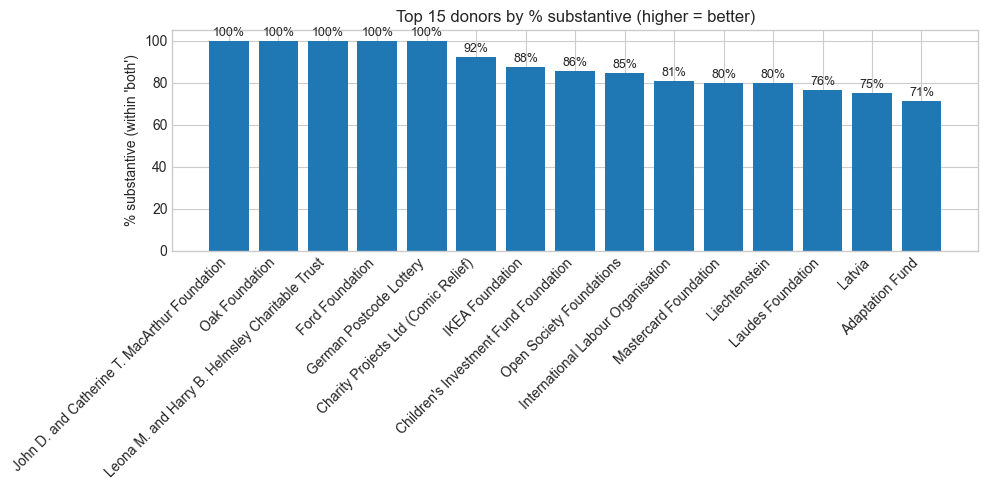

In [85]:
def plot_donor_pct_substantive(donors_df, top_n=15):
    d = donors_df.sort_values("pct_substantive", ascending=False).head(top_n)
    x = np.arange(len(d))
    y = d["pct_substantive"].values
    labels = d[COLS["donor"]].astype(str).values

    plt.figure(figsize=(10, 5))
    plt.bar(x, y)
    plt.xticks(x, labels, rotation=45, ha="right")
    plt.ylabel("% substantive (within 'both')")
    plt.title(f"Top {top_n} donors by % substantive (higher = better)")
    # annotate bars
    for i, v in enumerate(y):
        plt.text(i, v + 1, f"{v:.0f}%", ha="center", va="bottom", fontsize=9)
    plt.ylim(0, max(100, y.max() + 5))
    plt.tight_layout()
    plt.show()

plot_donor_pct_substantive(donors, top_n=15)


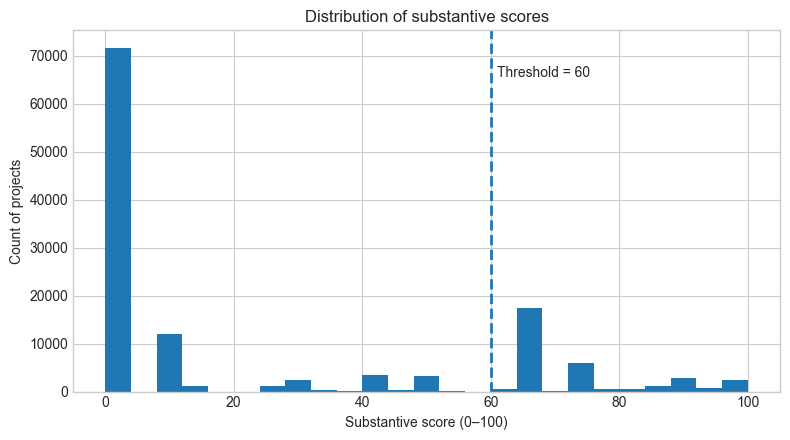

In [86]:
def plot_score_hist(scored_df, threshold=60):
    s = scored_df["substantive_score"].astype(float).values
    plt.figure(figsize=(8, 4.5))
    plt.hist(s, bins=25)
    plt.axvline(threshold, linestyle="--", linewidth=2)
    plt.xlabel("Substantive score (0–100)")
    plt.ylabel("Count of projects")
    plt.title("Distribution of substantive scores")
    # annotate threshold
    plt.text(threshold + 1, plt.ylim()[1]*0.9, f"Threshold = {threshold}", va="top")
    plt.tight_layout()
    plt.show()

plot_score_hist(scored, threshold=60)


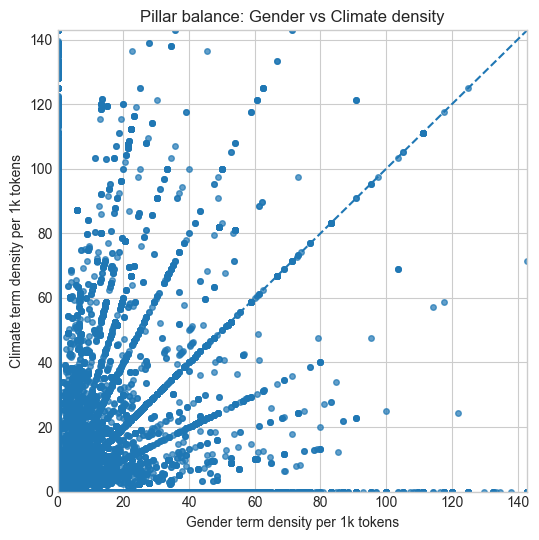

In [87]:
def plot_g_vs_c_density(scored_df):
    gx = scored_df["g_density_1k"].astype(float).values
    cy = scored_df["c_density_1k"].astype(float).values

    plt.figure(figsize=(5.5, 5.5))
    plt.scatter(gx, cy, s=16, alpha=0.7)
    lim = max(np.percentile(gx, 99), np.percentile(cy, 99))
    plt.plot([0, lim], [0, lim], linestyle="--", linewidth=1.5)  # balance line
    plt.xlim(0, lim); plt.ylim(0, lim)
    plt.xlabel("Gender term density per 1k tokens")
    plt.ylabel("Climate term density per 1k tokens")
    plt.title("Pillar balance: Gender vs Climate density")
    plt.tight_layout()
    plt.show()

plot_g_vs_c_density(scored)


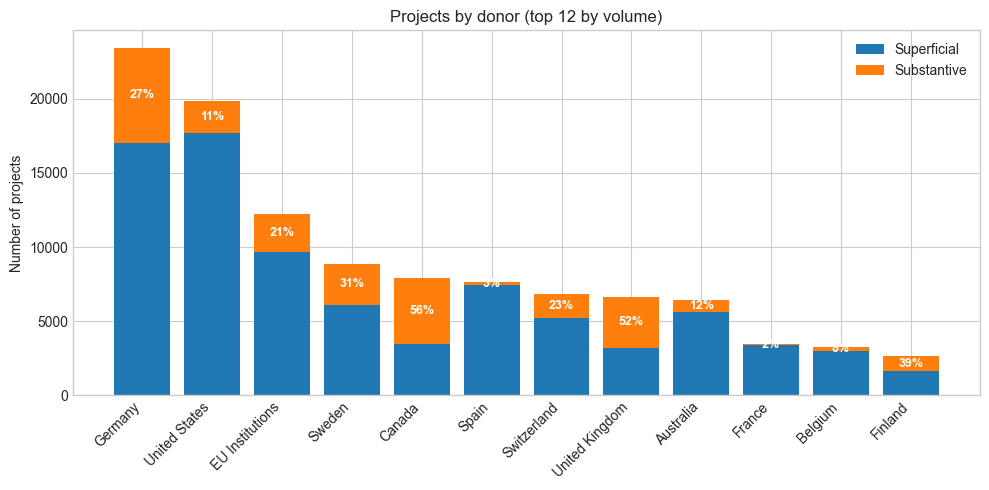

In [88]:
def plot_donor_stack_counts(scored_df, top_n=12):
    tmp = (scored_df
           .groupby(COLS["donor"])["nlp_label_final"]
           .value_counts()
           .unstack(fill_value=0)
           .rename(columns={0: "Superficial", 1: "Substantive"})
           .reset_index())
    tmp["Total"] = tmp["Superficial"] + tmp["Substantive"]
    tmp = tmp.sort_values("Total", ascending=False).head(top_n)

    x = np.arange(len(tmp))
    sub = tmp["Substantive"].values
    sup = tmp["Superficial"].values
    total = tmp["Total"].values
    labels = tmp[COLS["donor"]].astype(str).values

    plt.figure(figsize=(10, 5))
    plt.bar(x, sup, label="Superficial", color="tab:blue")
    plt.bar(x, sub, bottom=sup, label="Substantive", color="tab:orange")
    plt.xticks(x, labels, rotation=45, ha="right")
    plt.ylabel("Number of projects")
    plt.title(f"Projects by donor (top {top_n} by volume)")
    plt.legend()

    # Add percentage labels
    for i, (s, t) in enumerate(zip(sub, total)):
        pct = 100 * s / t if t > 0 else 0
        plt.text(i, sup[i] + s/2, f"{pct:.0f}%", ha="center", va="center", color="white", fontsize=9, fontweight="bold")

    plt.tight_layout()
    plt.show()

plot_donor_stack_counts(scored, top_n=12)


In [89]:
crs_data1.groupby(['DonorName'])['ProjectNumber'].size().sort_values(ascending=False)

DonorName
United States                   27710
Canada                          24851
Germany                         24622
EU Institutions                 13161
Australia                       10602
                                ...  
Global Affairs Canada               0
Gatsby Charitable Foundation        0
French Development Agency           0
Free State of Saxony                0
Youth and Sports Ministry           0
Name: ProjectNumber, Length: 382, dtype: int64

In [90]:
grouped_df.groupby(['DonorName'])['ProjectNumber'].size().sort_values(ascending=False)

DonorName
Germany                         23440
United States                   19833
EU Institutions                 12244
Sweden                           8852
Canada                           7908
                                ...  
Global Affairs Canada               0
Gatsby Charitable Foundation        0
French Development Agency           0
Free State of Saxony                0
Youth and Sports Ministry           0
Name: ProjectNumber, Length: 382, dtype: int64

Orange segments represent projects with strong, substantive integration according to NLP text analysis, while blue segments represent projects with superficial or one-sided integration.
This helps identify donors who are systematically using the "both" marker accurately versus those who may be overusing it.

Some donors (e.g., Canada – 72% substantive) are consistently using the marker accurately.

Others (e.g., United States – 11% substantive) show a high number of “both” projects but most are superficial → likely over-tagging.

In [91]:
substantive_examples = scored.loc[scored["nlp_label_final"] == 1]
superficial_examples = scored.loc[scored["nlp_label_final"] == 0]

print("Substantive count:", len(substantive_examples))
print("Superficial count:", len(superficial_examples))

Substantive count: 32070
Superficial count: 95755


In [92]:
# Top 5 strongest "both" projects
top_sub = substantive_examples.sort_values("substantive_score", ascending=False).head(5)
display(top_sub[[COLS["id"], COLS["donor"], COLS["title"], "substantive_score"]])

# Bottom 5 weakest "both" projects
bottom_sup = superficial_examples.sort_values("substantive_score", ascending=True).head(5)
display(bottom_sup[[COLS["id"], COLS["donor"], COLS["title"], "substantive_score"]])

,ProjectNumber,DonorName,ProjectTitle,substantive_score
77073,7F-10293.01.53,Switzerland,Grassroots women building resilience and peace...,100.0
102814,P011972001,Canada,Gender Transformative Climate Adaptation/Adapt...,100.0
121402,SE-0-SE-6-6107013201-ALB-15152,Sweden,Inter-Parliamentary Union IPU 2019-2021 - Inte...,100.0
102820,P011972001,Canada,Gender Transformative Climate Adaptation/Adapt...,100.0
102819,P011972001,Canada,Gender Transformative Climate Adaptation/Adapt...,100.0


,ProjectNumber,DonorName,ProjectTitle,substantive_score
4,001561,Portugal,Local Scholarships,0.0
74297,7F-08038.03.03,Switzerland,Gestion des Eaux de Ruissellement dans le Tcha...,0.0
74296,7F-08038.03.02,Switzerland,Gestion des Eaux de Ruissellement dans le Tcha...,0.0
74295,7F-08038.03.02,Switzerland,Gestion des Eaux de Ruissellement dans le Tcha...,0.0
74294,7F-08038.03.01,Switzerland,Gestion des Eaux de Ruissellement dans le Tcha...,0.0


In [93]:
def plot_donor_sector_heatmap(donor_sector_df, 
                              top_n_donors=10, 
                              top_n_sectors=8,
                              value_col="pct_substantive"):
    """
    Plots a heatmap of donor × sector showing % substantive projects.

    Parameters
    ----------
    donor_sector_df : pd.DataFrame
        Output from validate_both_marked()["donor_sector_breakdown"]
        Must have columns: DonorName, SectorName, pct_substantive
    top_n_donors : int
        Number of top donors (by project count) to include.
    top_n_sectors : int
        Number of top sectors (by project count) to include.
    value_col : str
        Column to plot (pct_substantive or avg_score)
    """
    # Pick top donors/sectors by number of projects
    top_donors = (donor_sector_df.groupby(COLS["donor"])["n_projects"]
                  .sum()
                  .nlargest(top_n_donors)
                  .index)
    top_sectors = (donor_sector_df.groupby(COLS["sector"])["n_projects"]
                   .sum()
                   .nlargest(top_n_sectors)
                   .index)

    df_plot = donor_sector_df[
        donor_sector_df[COLS["donor"]].isin(top_donors)
        & donor_sector_df[COLS["sector"]].isin(top_sectors)
    ]

    pivot = df_plot.pivot(index=COLS["donor"], 
                          columns=COLS["sector"], 
                          values=value_col)

    plt.figure(figsize=(1.2*len(top_sectors), 0.6*len(top_donors)+3))
    sns.heatmap(pivot, annot=True, fmt=".0f", cmap="YlGnBu", cbar_kws={'label': '% Substantive'})
    plt.title(f"Donor × Sector: {value_col.replace('_',' ').title()}")
    plt.xlabel("Sector")
    plt.ylabel("Donor")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

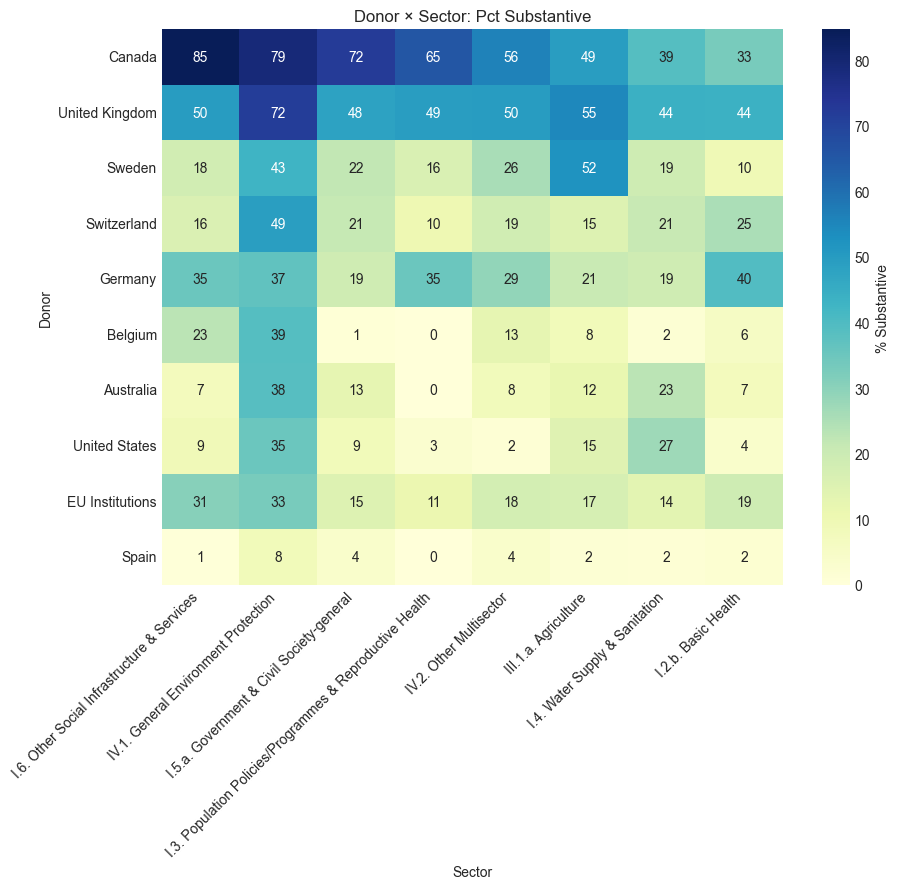

In [94]:
donor_sector = out["donor_sector_breakdown"]

# Plot top 10 donors and top 8 sectors
plot_donor_sector_heatmap(donor_sector, top_n_donors=10, top_n_sectors=8)

## SUBSTANTIVENESS BY SECTOR

In [95]:
def plot_sector_avg_substantive(donor_sector_df, top_n=10, weighted=True):
    """
    Horizontal bar chart: average % substantive by sector across all donors, sorted descending.
    """
    sec = COLS["sector"]
    df = donor_sector_df.copy()

    if weighted:
        grp = (df.assign(sub_count = df["pct_substantive"] * df["n_projects"] / 100.0)
                 .groupby(sec)
                 .agg(total_projects=("n_projects","sum"),
                      total_substantive=("sub_count","sum"))
                 .reset_index())
        grp["pct_substantive_avg"] = 100.0 * grp["total_substantive"].div(grp["total_projects"].replace(0, np.nan))
    else:
        grp = (df.groupby(sec)
                 .agg(pct_substantive_avg=("pct_substantive","mean"),
                      total_projects=("n_projects","sum"))
                 .reset_index())
    #print(grp)
    grp['pct_substantive_avg'] = grp['pct_substantive_avg'].fillna(0)
    # Sort by percentage descending, pick top N
    grp = grp.sort_values("pct_substantive_avg", ascending=True).tail(top_n)
    

    # Plot
    plt.figure(figsize=(10, 0.5*len(grp) + 2))
    y_pos = np.arange(len(grp))
    plt.barh(y_pos, grp["pct_substantive_avg"], color="steelblue")
    plt.yticks(y_pos, grp[sec])
    plt.xlabel("% Substantive")
    plt.title("Average % Substantive by Sector (Project-Weighted)" if weighted else
              "Average % Substantive by Sector (Unweighted)")
    
    # Annotate values
    for i, v in enumerate(grp["pct_substantive_avg"]):
        plt.text(v + 1, i, f"{v:.0f}%", va="center")
    plt.xlim(0, max(100, (grp["pct_substantive_avg"].max() if len(grp) else 0) + 10))
    plt.tight_layout()
    plt.show()

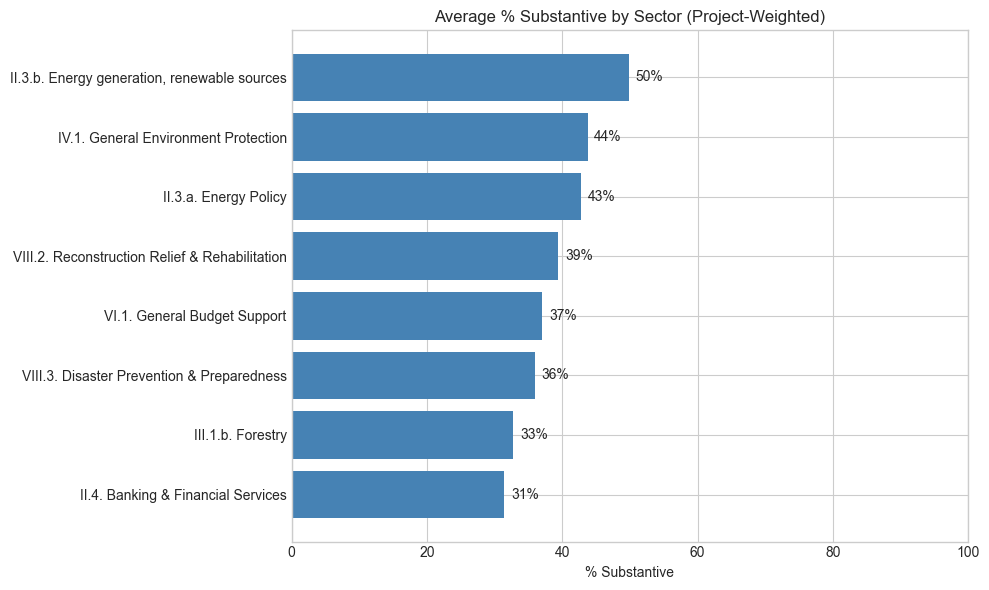

In [96]:
donor_sector = out["donor_sector_breakdown"]
plot_sector_avg_substantive(donor_sector, top_n=8, weighted=True)   # recommended

Top Sector: II.3.b. Energy generation, renewable sources → 50% substantive.
→ Projects here are most consistently well-integrated (likely strong GxC co-benefits).

IV.1. General Environment Protection and II.3.a. Energy Policy also perform above 40%, showing relatively strong integration.

Lower sectors: Banking & Financial Services, Forestry, Disaster Prevention are below ~35%, which may indicate over-tagging or superficial integration in many cases.

## CREATING A COMPOSITE SCORE

In [97]:
crs_data1['SectorCode'].unique()

[140, 311, 430, 410, 232, ..., '323', 123, 234, 930, 600]
Length: 75
Categories (97, object): [100, 110, 111, 112, ..., '910', '930', '998', 'VIII.1. Emergency Response']

In [98]:
crs_data1.shape

(166336, 57)

In [99]:
scored.shape

(127825, 12)

In [100]:
scored

,ProjectNumber,DonorName,SectorName,Year,ProjectTitle,substantive_score,g_density_1k,c_density_1k,pillar_balance,ac_density_1k,spread_sections,nlp_label_final
0,001561,Portugal,I.1.c. Secondary Education,2015.0,Local Scholarships,65.0,0.000000,50.000000,0.0,0.000000,2,1
1,001561,Portugal,I.1.c. Secondary Education,2016.0,Local Scholarships,65.0,0.000000,50.000000,0.0,0.000000,2,1
2,001561,Portugal,I.1.c. Secondary Education,2017.0,Local Scholarships,65.0,0.000000,50.000000,0.0,0.000000,2,1
3,001561,Portugal,I.1.c. Secondary Education,2018.0,Local Scholarships,65.0,0.000000,45.454545,0.0,0.000000,2,1
4,001561,Portugal,I.1.c. Secondary Education,2019.0,Local Scholarships,0.0,0.000000,0.000000,0.0,0.000000,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...
127820,NaN,Japan,III.1.a. Agriculture,2023.0,TC AGGREGATED ACTIVITIES,0.0,0.000000,0.000000,0.0,0.000000,0,0
127821,NaN,Liechtenstein,III.1.a. Agriculture,2023.0,"Empowering rural women in Chiundura, Thulilish...",90.0,58.823529,58.823529,1.0,0.000000,2,1
127822,NaN,Slovenia,III.2.a. Industry,2023.0,Development of an inclusive and sustainable gl...,10.0,0.000000,0.000000,0.0,6.079027,0,0
127823,NaN,Slovenia,III.1.b. Forestry,2023.0,Preparation on cooperation in the field of af...,75.0,0.000000,13.824885,0.0,9.216590,2,1


In [101]:
SECTOR_PRIOR = {
    # HIGH PRIORITY for integration (0.85–1.0)
    "I.4. Water Supply & Sanitation": 0.95,
    "III.1.a. Agriculture": 1.00,
    "II.3.b. Energy generation, renewable sources": 0.95,
    "II.3.f. Energy distribution": 0.85,
    "II.3.a. Energy Policy": 0.90,
    "IV.1. General Environment Protection": 0.95,
    "VIII.3. Disaster Prevention & Preparedness": 0.90,
    "III.1.b. Forestry": 0.85,

    # MEDIUM PRIORITY (0.6–0.8) – integration is relevant but often indirect
    "I.5.a. Government & Civil Society-general": 0.75,
    "I.2.a. Health, General": 0.7,
    "I.6. Other Social Infrastructure & Services": 0.65,
    "I.3. Population Policies/Programmes & Reproductive Health": 0.65,
    "II.4. Banking & Financial Services": 0.6,
    "II.1. Transport & Storage": 0.7,
    "I.1.a. Education, Level Unspecified": 0.65,
    "I.1.d. Post-Secondary Education": 0.6,
    "I.2.b. Basic Health": 0.7,
    "I.1.c. Secondary Education": 0.65,
    "I.1.b. Basic Education": 0.65,
    "I.5.b. Conflict, Peace & Security": 0.7,
    "VIII.2. Reconstruction Relief & Rehabilitation": 0.75,
    "VIII.1. Emergency Response": 0.7,

    # LOW PRIORITY (≤0.5) – likely low direct GxC link
    "III.2.a. Industry": 0.5,
    "III.2.b. Mineral Resources & Mining": 0.4,
    "III.2.c. Construction": 0.45,
    "III.3.a. Trade Policies & Regulations": 0.4,
    "III.3.b. Tourism": 0.3,
    "II.2. Communications": 0.45,
    "II.5. Business & Other Services": 0.5,
    "II.3.c. Energy generation, non-renewable sources": 0.3,
    "II.3.e. Nuclear energy plants": 0.25,
    "II.3.d. Hybrid energy plants": 0.35,
    "VI.2. Development Food Assistance": 0.55,
    "VI.1. General Budget Support": 0.45,
    "VI.3. Other Commodity Assistance": 0.45,
    "VII. Action Relating to Debt": 0.3,
    "Administrative Costs of Donors": 0.0,
    "Refugees in Donor Countries": 0.25,
    "IX. Unallocated / Unspecified": 0.3,
    "unspecified":0.3
}

In [102]:
def compute_cis_sector_only(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    
    # Normalize text score
    out["TextComponent"] = out["substantive_score"].clip(0, 100) / 100.0
    
    # Sector weight (fallback = 0.5)
    out["SectorComponent"] = out["SectorName"].map(SECTOR_PRIOR).fillna(0.5)
    
    # Balance component
    def _balance(g, c):
        hi = max(g or 0, c or 0)
        lo = min(g or 0, c or 0)
        return 0.0 if hi == 0 else lo / hi
    out["BalanceComponent"] = [_balance(g, c) for g, c in zip(out["g_density_1k"], out["c_density_1k"])]
    
    # Weighted CIS (simple & transparent)
    w_text, w_sector, w_balance = 0.5, 0.3, 0.2
    out["CIS"] = 100 * (w_text * out["TextComponent"] +
                        w_sector * out["SectorComponent"] +
                        w_balance * out["BalanceComponent"])
    
    # Band the score
    bins = [0, 40, 60, 80, 100]
    labels = ["Low", "Moderate", "Strong", "Exemplary"]
    out["CIS_band"] = pd.cut(out["CIS"], bins=bins, labels=labels, include_lowest=True)
    
    return out[["ProjectNumber", "DonorName", "SectorName", "substantive_score", 
                "TextComponent", "SectorComponent", "BalanceComponent", "CIS", "CIS_band"]]

In [103]:
cis_df = compute_cis_sector_only(scored)

In [104]:
cis_df

,ProjectNumber,DonorName,SectorName,substantive_score,TextComponent,SectorComponent,BalanceComponent,CIS,CIS_band
0,001561,Portugal,I.1.c. Secondary Education,65.0,0.65,0.65,0.0,52.0,Moderate
1,001561,Portugal,I.1.c. Secondary Education,65.0,0.65,0.65,0.0,52.0,Moderate
2,001561,Portugal,I.1.c. Secondary Education,65.0,0.65,0.65,0.0,52.0,Moderate
3,001561,Portugal,I.1.c. Secondary Education,65.0,0.65,0.65,0.0,52.0,Moderate
4,001561,Portugal,I.1.c. Secondary Education,0.0,0.00,0.65,0.0,19.5,Low
...,...,...,...,...,...,...,...,...,...
127820,NaN,Japan,III.1.a. Agriculture,0.0,0.00,1.00,0.0,30.0,Low
127821,NaN,Liechtenstein,III.1.a. Agriculture,90.0,0.90,1.00,1.0,95.0,Exemplary
127822,NaN,Slovenia,III.2.a. Industry,10.0,0.10,0.50,0.0,20.0,Low
127823,NaN,Slovenia,III.1.b. Forestry,75.0,0.75,0.85,0.0,63.0,Strong


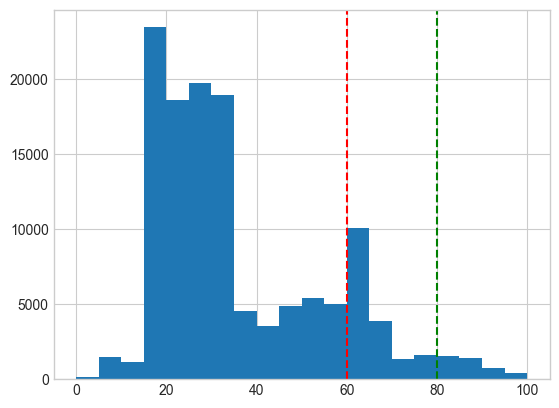

In [105]:
plt.hist(cis_df["CIS"], bins=20)
plt.axvline(60, color="red", linestyle="--", label="Strong threshold")
plt.axvline(80, color="green", linestyle="--", label="Exemplary threshold")

Distribution is skewed to the left. Few exemplary projects

In [106]:
def plot_cis_by_donor(cis_df, cis_col="CIS", donor_col="DonorName", top_n=10):
    df = cis_df.copy()
    df = df.groupby(donor_col, as_index=False)[cis_col].mean()
    df[cis_col] = df[cis_col].fillna(0)
    df = df.sort_values(cis_col, ascending=True).tail(top_n)

    plt.figure(figsize=(8, 0.5*len(df) + 2))
    plt.barh(df[donor_col], df[cis_col], color="teal")
    for i, v in enumerate(df[cis_col]):
        plt.text(v + 1, i, f"{v:.1f}", va="center")
    plt.xlabel("Average Composite Integration Score")
    plt.title(f"Top {top_n} Donors by Average CIS")
    plt.xlim(0, 100)
    plt.tight_layout()
    plt.show()


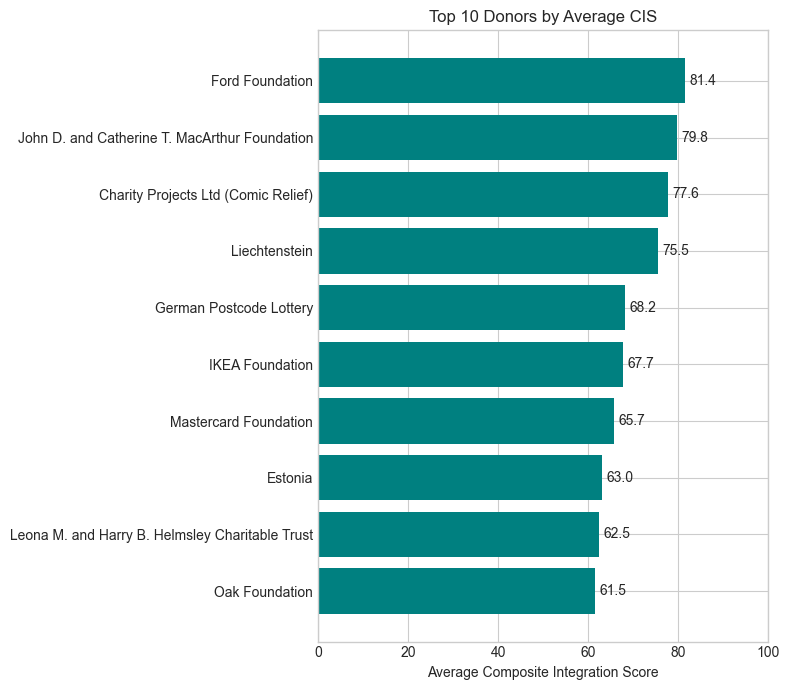

In [107]:
plot_cis_by_donor(cis_df)

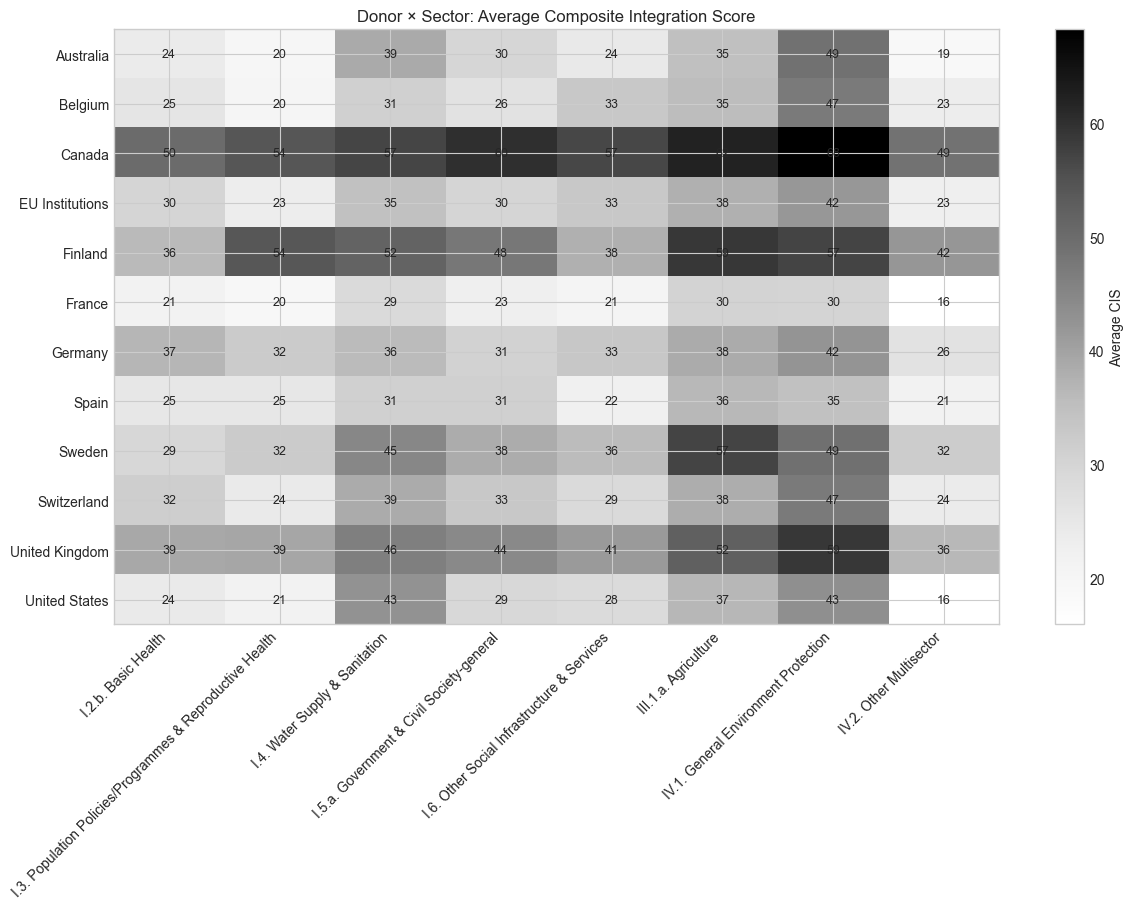

In [108]:
def heatmap_cis_donor_sector(cis_df,
                             cis_col="CIS",
                             donor_col=None,
                             sector_col=None,
                             top_n_donors=12,
                             top_n_sectors=8,
                             min_cells=5):
    """
    Donor × Sector heatmap of average CIS.
    - Keeps top donors/sectors by project count for readability.
    - Drops sparse cells (fewer than min_cells projects) to avoid noisy averages.
    """

    # --- resolve columns
    if donor_col is None:
        donor_col = COLS.get("donor", "donor")
    if sector_col is None:
        sector_col = COLS.get("sector", "sector")

    # --- validate
    needed = {donor_col, sector_col, cis_col}
    missing = needed - set(cis_df.columns)
    if missing:
        raise ValueError(f"Missing columns: {missing}. Need {needed}")

    df = cis_df[[donor_col, sector_col, cis_col]].copy()
    df[cis_col] = pd.to_numeric(df[cis_col], errors="coerce")
    df = df.dropna(subset=[donor_col, sector_col, cis_col])
    if df.empty:
        print("No data to plot after cleaning.")
        return

    # --- pick top donors/sectors by volume
    top_donors = (df[donor_col].value_counts().head(top_n_donors).index)
    top_sectors = (df[sector_col].value_counts().head(top_n_sectors).index)
    df = df[df[donor_col].isin(top_donors) & df[sector_col].isin(top_sectors)]

    if df.empty:
        print("No overlap between top donors and top sectors.")
        return

    # --- aggregate and filter sparse cells
    agg = (df.groupby([donor_col, sector_col])
             .agg(avg_cis=(cis_col, "mean"),
                  n=("CIS", "size"))  # count of records in the cell
             .reset_index())
    # Note: n above is wrong—fix:
    agg = (df.groupby([donor_col, sector_col])
             .agg(avg_cis=(cis_col, "mean"),
                  n=(cis_col, "size"))
             .reset_index())

    agg = agg[agg["n"] >= min_cells]
    if agg.empty:
        print(f"No cells meet min_cells >= {min_cells}. Try lowering min_cells.")
        return

    # --- pivot for heatmap
    pivot = agg.pivot(index=donor_col, columns=sector_col, values="avg_cis")

    # --- plot
    plt.figure(figsize=(1.2*len(pivot.columns) + 3, 0.6*len(pivot.index) + 2))
    # draw cells manually (pure matplotlib)
    im = plt.imshow(pivot.values, aspect="auto", interpolation="nearest")
    plt.colorbar(im, label="Average CIS")

    # ticks/labels
    plt.xticks(np.arange(pivot.shape[1]), pivot.columns, rotation=45, ha="right")
    plt.yticks(np.arange(pivot.shape[0]), pivot.index)

    # annotate with values
    for i in range(pivot.shape[0]):
        for j in range(pivot.shape[1]):
            val = pivot.values[i, j]
            if not np.isnan(val):
                plt.text(j, i, f"{val:.0f}", ha="center", va="center", fontsize=9)

    plt.title("Donor × Sector: Average Composite Integration Score")
    plt.tight_layout()
    plt.show()
heatmap_cis_donor_sector(cis_df)

In [109]:
#Dropping sector name "admin costs" and other non-relevant sectors
#instead of looking at the three markers separately, combine to create a bucket with categories "Gender only, climate only,
#Both or neither". This way projects with missing markers are grouped in the neither bucket